# Network Traffic Analysis
**SIL765 — Assignment 3**


**Saharsh Laud - 2024MCS2002**

This notebook consolidates all four phases of the network traffic analysis assignment:
- **Part 1** — Basic Network Traffic Statistics
- **Part 2** — Traffic Estimation Using Sublinear Space
- **Part 3** — Advanced Anomaly Detection
- **Part 4** — Deep Security Threat Analysis

The dataset consists of multiple CSV files exported from a firewall/IDS, containing detailed flow-level records. All phases share a single data load and derived columns to avoid redundant preprocessing.

## Setup — Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import mmh3, math, sys, time, re, warnings, glob, os
from bitarray import bitarray
from collections import defaultdict

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

# ── Configurable parameters ──
DATA_DIR             = '.'
K_PROTOCOLS          = 5       # top-k protocols to display (1.2)
TOP_N_IPS            = 10      # top-N IPs (1.3)
TOP_PAIRS            = 3       # top src-dst pairs (1.5)
TIME_WINDOW          = '1h'
CONSISTENCY_THRESH   = 0.75    # fraction of windows an IP must appear in (1.6)
RESAMPLE_FREQ        = '5min'
SPIKE_SIGMA          = 3       # z-score multiplier for spike / anomaly thresholds

# Phase 3 thresholds (calibrated from dataset diagnostics)
LONG_CONN_THRESHOLD  = 1909    # seconds  (mean + 3*std of duration)
FANIN_THRESHOLD      = 10      # distinct sources per dest per hour
PORTSCAN_THRESHOLD   = 100     # distinct destination ports per source IP
FLOW_VOL_THRESHOLD   = 2028    # flows per source IP (99th percentile)
MULTIPROTO_THRESHOLD = 2       # distinct protocols in a 10-min window

# Phase 4 additional parameters
SLOW_DDOS_WINDOW     = '30min'
BEACON_MIN_PERIODS   = 5       # min repeated intervals to flag C2
BEACON_REGULARITY    = 0.25    # CV threshold for beaconing detection
IP_HOP_THRESHOLD     = 3       # distinct source IPs to same dst:port/10-min

print("Configuration loaded.")

Configuration loaded.


## Data Loading

We load all six CSV files and union them into a single DataFrame. Only columns needed across all phases are loaded to keep memory usage reasonable. Timestamps are parsed once here; all derived columns (duration, totalBytes, packetSize, is_attack) are created up-front so every phase can reuse them without re-computing.

In [2]:
# Load all CSV files — using a superset of columns required across all 4 phases
USECOLS = [
    'source', 'destination', 'sourcePort', 'destinationPort',
    'protocolName', 'appName', 'direction', 'Label',
    'totalSourceBytes', 'totalDestinationBytes',
    'totalSourcePackets', 'totalDestinationPackets',
    'startDateTime', 'stopDateTime',
    'sourceTCPFlagsDescription', 'destinationTCPFlagsDescription',
    'sourcePayloadAsUTF'
]

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, 'network_analysis_data*.csv')))
print(f"Found {len(csv_files)} CSV files.")

chunks = []
for fpath in csv_files:
    chunk = pd.read_csv(
        fpath, usecols=USECOLS, low_memory=False,
        dtype={'source': str, 'destination': str, 'protocolName': str,
               'appName': str, 'Label': str, 'direction': str,
               'sourceTCPFlagsDescription': str,
               'destinationTCPFlagsDescription': str,
               'sourcePayloadAsUTF': str}
    )
    chunks.append(chunk)
    print(f"  {os.path.basename(fpath)}: {len(chunk):,} rows")

df = pd.concat(chunks, ignore_index=True)
df.dropna(subset=['source', 'destination'], inplace=True)

# Parse timestamps
df['startDateTime'] = pd.to_datetime(df['startDateTime'], format='mixed', errors='coerce')
df['stopDateTime']  = pd.to_datetime(df['stopDateTime'],  format='mixed', errors='coerce')
df.dropna(subset=['startDateTime'], inplace=True)

# Derived columns used across all phases
df['duration_sec'] = (df['stopDateTime'] - df['startDateTime']).dt.total_seconds()
df.loc[df['duration_sec'] < 0, 'duration_sec'] = np.nan
df['totalBytes']   = df['totalSourceBytes'].fillna(0)   + df['totalDestinationBytes'].fillna(0)
df['totalPackets'] = df['totalSourcePackets'].fillna(0) + df['totalDestinationPackets'].fillna(0)
df['packetSize']   = np.where(df['totalPackets'] > 0,
                               df['totalBytes'] / df['totalPackets'], np.nan)
df['is_attack']    = df['Label'].str.lower().str.strip() != 'normal'
df['hour_of_day']  = df['startDateTime'].dt.hour

# Time-indexed copy used in Phases 1, 3, 4
df_ts = df.set_index('startDateTime').sort_index()

print(f"\nDataset: {len(df):,} flows | {df['is_attack'].sum():,} attack | {df['is_attack'].mean()*100:.2f}% attack rate")
print(f"Time range: {df['startDateTime'].min()} → {df['startDateTime'].max()}")
print(f"Memory: {df.memory_usage(deep=True).sum()/1024**2:.1f} MB")

Found 6 CSV files.
  network_analysis_data1.csv: 171,380 rows
  network_analysis_data2.csv: 133,193 rows
  network_analysis_data3.csv: 275,528 rows
  network_analysis_data4.csv: 397,595 rows
  network_analysis_data5.csv: 571,698 rows
  network_analysis_data6.csv: 522,263 rows

Dataset: 2,071,657 flows | 68,910 attack | 3.33% attack rate
Time range: 2010-06-11 20:10:00 → 2010-06-17 23:58:00
Memory: 1266.8 MB


---
## Phase 1 — Basic Network Traffic Statistics

We start with a high-level characterisation of the traffic: flow counts, protocol distribution, most active IP addresses, packet size statistics, top communicating pairs, temporal patterns, and traffic spikes.

### 1.1 — Total Flow Count

In [3]:
total_flows  = len(df)
normal_flows = (df['Label'].str.lower() == 'normal').sum()
attack_flows = total_flows - normal_flows

print(f"Total flows  : {total_flows:,}")
print(f"Normal flows : {normal_flows:,}  ({normal_flows/total_flows*100:.2f}%)")
print(f"Attack flows : {attack_flows:,}  ({attack_flows/total_flows*100:.2f}%)")

Total flows  : 2,071,657
Normal flows : 2,002,747  (96.67%)
Attack flows : 68,910  (3.33%)


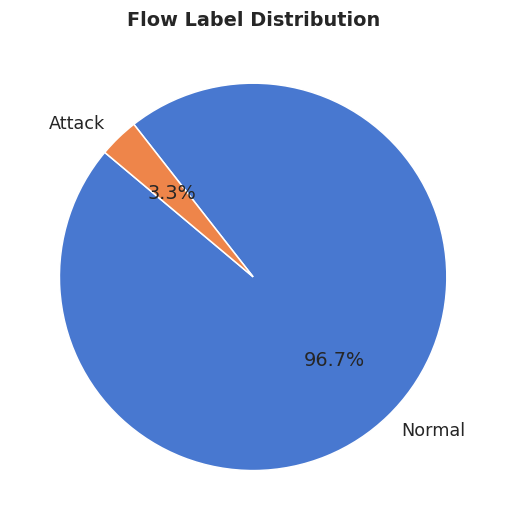

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
label_counts = df['Label'].value_counts()
ax.pie(label_counts.values, labels=label_counts.index,
       autopct='%1.1f%%', startangle=140,
       colors=sns.color_palette('muted', len(label_counts)))
ax.set_title('Flow Label Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('1_1_flow_labels.png', bbox_inches='tight')
plt.show()

### 1.2 — Top K Most Frequent Protocols

Protocol distribution tells us what kind of traffic dominates. TCP dominance is normal in enterprise networks (HTTP/S, SSH); heavy UDP may suggest DNS abuse or scanning; elevated ICMP can signal ping sweeps.

In [5]:
protocol_counts = df['protocolName'].value_counts()
top_k = protocol_counts.head(K_PROTOCOLS)
print(top_k.to_frame('flow_count')
       .assign(pct=lambda x: (x['flow_count']/total_flows*100).round(6)))

              flow_count        pct
protocolName                       
tcp_ip           1644056  79.359469
udp_ip            419246  20.237230
icmp_ip             8211   0.396349
igmp                  77   0.003717
ip                    66   0.003186


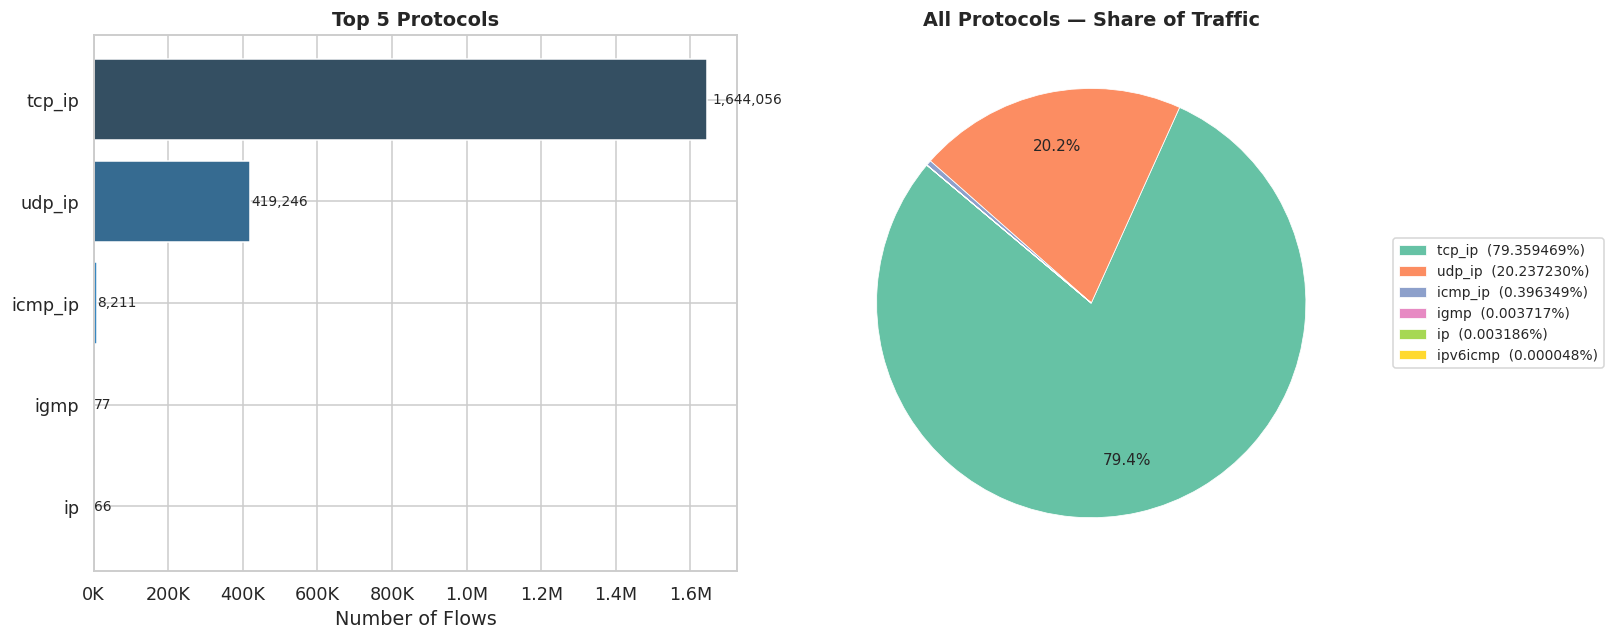

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(top_k.index[::-1], top_k.values[::-1],
             color=sns.color_palette('Blues_d', K_PROTOCOLS))
axes[0].set_xlabel('Number of Flows')
axes[0].set_title(f'Top {K_PROTOCOLS} Protocols', fontweight='bold')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
for i, v in enumerate(top_k.values[::-1]):
    axes[0].text(v*1.01, i, f'{v:,}', va='center', fontsize=9)

total = protocol_counts.sum()
def smart_autopct(pct): return f'{pct:.1f}%' if pct >= 1.0 else ''
wedges, _, autotexts = axes[1].pie(
    protocol_counts.values, labels=None, autopct=smart_autopct,
    startangle=140, pctdistance=0.75,
    colors=sns.color_palette('Set2', len(protocol_counts)),
    wedgeprops=dict(linewidth=0.5, edgecolor='white'))
[at.set_fontsize(10) for at in autotexts]
axes[1].legend(wedges,
    [f'{n}  ({v/total*100:.6f}%)' for n, v in zip(protocol_counts.index, protocol_counts.values)],
    loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=9)
axes[1].set_title('All Protocols — Share of Traffic', fontweight='bold')
plt.tight_layout()
plt.savefig('1_2_protocols.png', bbox_inches='tight')
plt.show()

### 1.3 — Top 10 Most Active IPs

We rank IPs by **total bytes** (primary metric) and also by flow count (secondary). Bytes better reflects actual bandwidth consumption, while flow count highlights chatty but low-volume hosts.

In [7]:
src_bytes = df.groupby('source')['totalSourceBytes'].sum().nlargest(TOP_N_IPS)
dst_bytes = df.groupby('destination')['totalDestinationBytes'].sum().nlargest(TOP_N_IPS)
src_flows = df['source'].value_counts().head(TOP_N_IPS)
dst_flows = df['destination'].value_counts().head(TOP_N_IPS)

print("Top 10 Source IPs by bytes sent:")
print(src_bytes.apply(lambda x: f'{x:,}').rename('bytes_sent').to_frame())
print("\nTop 10 Destination IPs by bytes received:")
print(dst_bytes.apply(lambda x: f'{x:,}').rename('bytes_received').to_frame())

Top 10 Source IPs by bytes sent:
                  bytes_sent
source                      
192.168.2.107  1,766,723,841
192.168.4.121    348,236,805
192.168.2.109    279,555,269
192.168.1.105    233,991,932
192.168.1.101    229,244,162
192.168.2.112    219,642,794
192.168.2.113    219,011,411
192.168.4.118    201,191,844
192.168.1.103    190,875,178
192.168.2.110    176,514,136

Top 10 Destination IPs by bytes received:
                bytes_received
destination                   
192.168.5.122    9,583,092,752
69.84.133.138    5,619,014,157
95.154.240.242   3,879,482,850
68.178.178.97    2,801,780,566
203.73.24.75     1,998,532,100
79.125.17.124    1,294,872,433
68.178.178.33    1,222,199,452
91.190.170.71    1,037,257,359
72.32.84.3         784,108,572
195.189.143.147    752,319,357


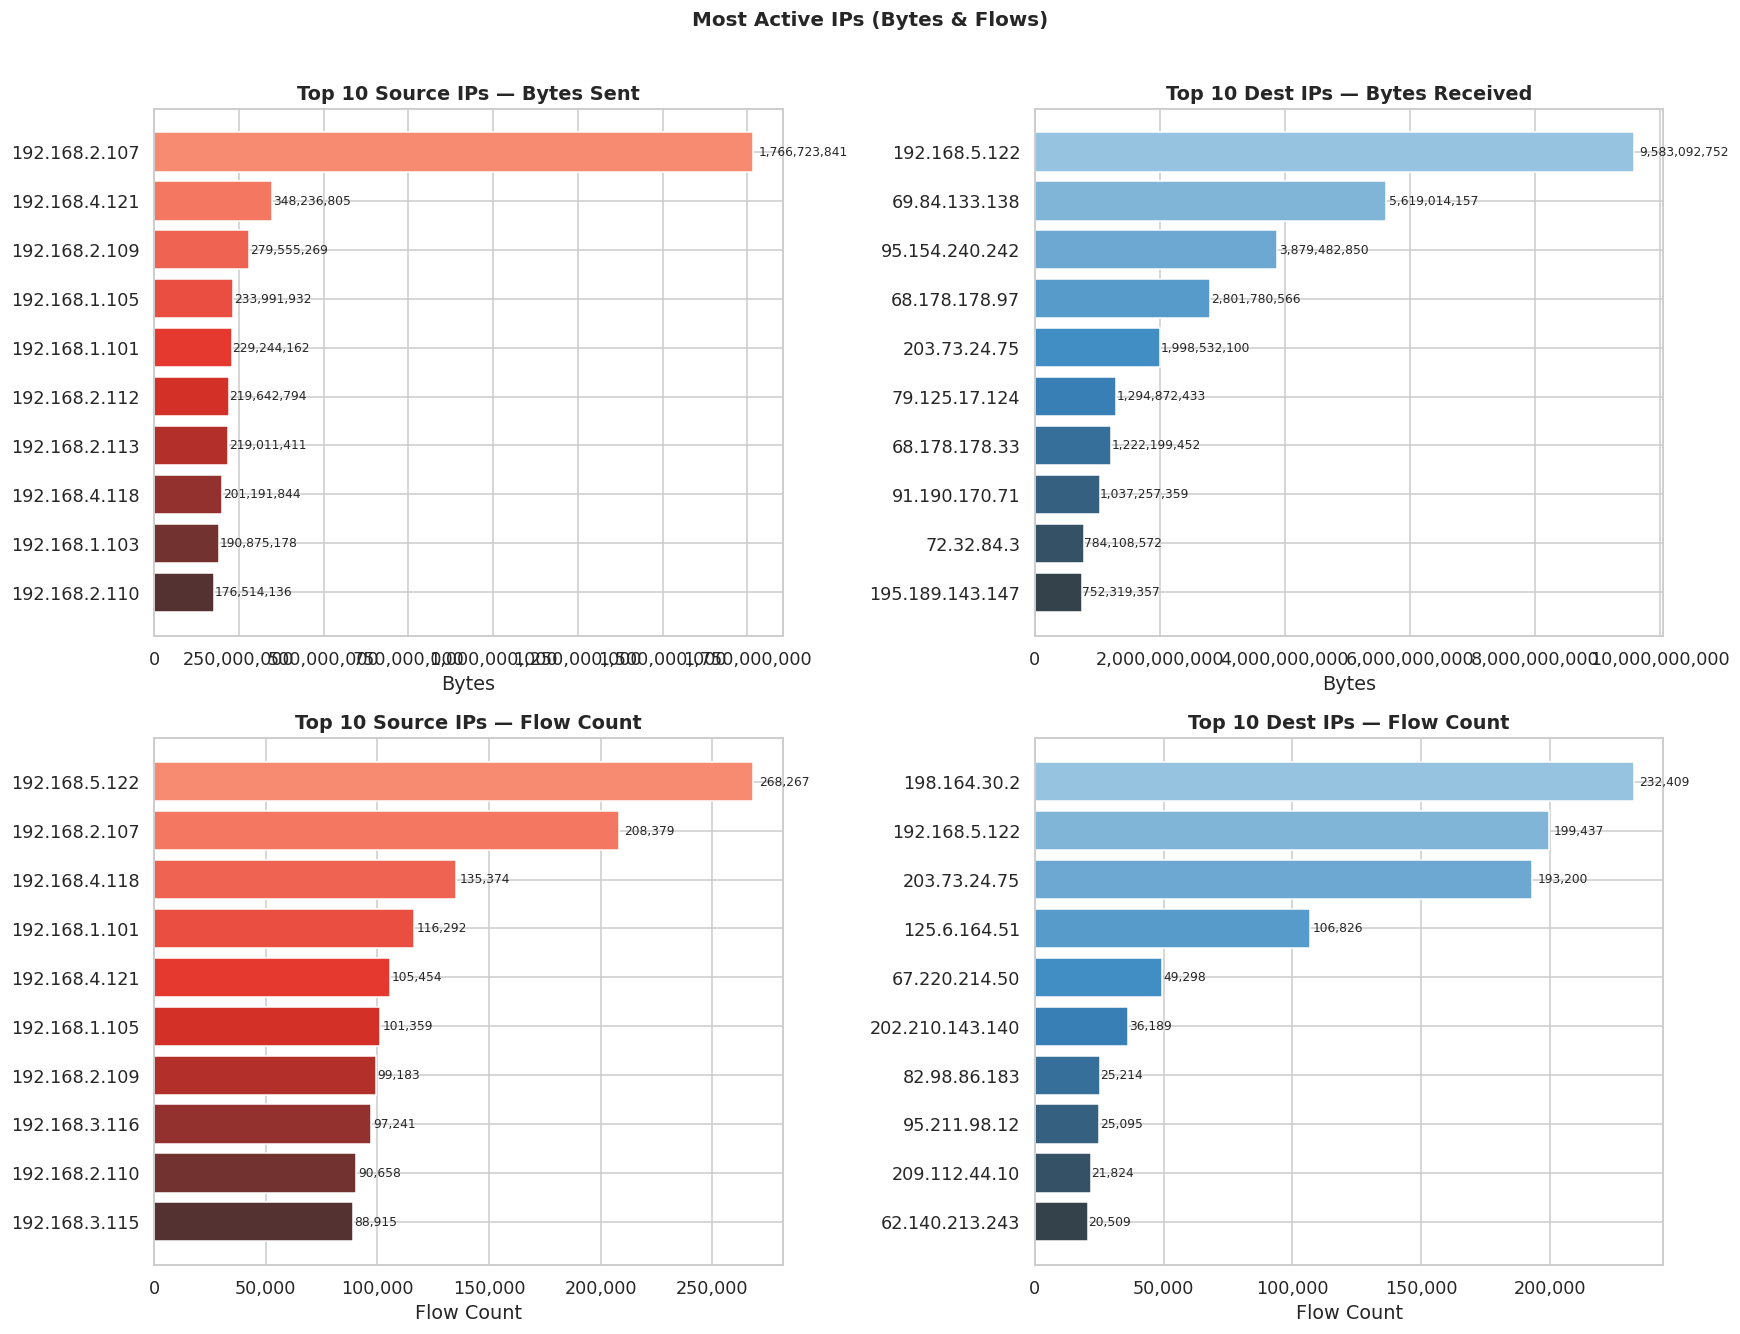

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
pal_src = sns.color_palette('Reds_d', TOP_N_IPS)
pal_dst = sns.color_palette('Blues_d', TOP_N_IPS)

def bar_h(ax, series, title, xlabel, palette):
    ax.barh(series.index[::-1], series.values[::-1], color=palette[::-1])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for i, v in enumerate(series.values[::-1]):
        ax.text(v*1.01, i, f'{v:,}', va='center', fontsize=8)

bar_h(axes[0,0], src_bytes, f'Top {TOP_N_IPS} Source IPs — Bytes Sent',    'Bytes',      pal_src)
bar_h(axes[0,1], dst_bytes, f'Top {TOP_N_IPS} Dest IPs — Bytes Received',  'Bytes',      pal_dst)
bar_h(axes[1,0], src_flows, f'Top {TOP_N_IPS} Source IPs — Flow Count',    'Flow Count', pal_src)
bar_h(axes[1,1], dst_flows, f'Top {TOP_N_IPS} Dest IPs — Flow Count',      'Flow Count', pal_dst)

plt.suptitle('Most Active IPs (Bytes & Flows)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('1_3_top_ips.png', bbox_inches='tight')
plt.show()

### 1.4 — Average Packet Size

Packet size is computed as total bytes / total packets per flow. If the distribution is heavily skewed (|skew| > 1), the median is a more representative central tendency than the mean — typical in mixed traffic with small control packets and large data transfers.

In [9]:
ps = df['packetSize'].dropna()
mean_ps, median_ps = ps.mean(), ps.median()
std_ps, skew_ps = ps.std(), ps.skew()

print(f"Mean packet size   : {mean_ps:.2f} bytes")
print(f"Median packet size : {median_ps:.2f} bytes")
print(f"Std deviation      : {std_ps:.2f} bytes")
print(f"Skewness           : {skew_ps:.4f}")

if abs(skew_ps) > 1:
    print(f"\nSkewness = {skew_ps:.2f} (|skew| > 1) — distribution is heavily skewed.")
    print(f"Mean ({mean_ps:.0f}) >> Median ({median_ps:.0f}) — mean is pulled by large flows.")
    print("Conclusion: the MEDIAN is a more representative measure here.")
else:
    print(f"\nSkewness = {skew_ps:.2f} — distribution is approximately symmetric.")
    print("Conclusion: the mean is reasonably representative.")

Mean packet size   : 315.79 bytes
Median packet size : 195.38 bytes
Std deviation      : 266.07 bytes
Skewness           : 1.0648

Skewness = 1.06 (|skew| > 1) — distribution is heavily skewed.
Mean (316) >> Median (195) — mean is pulled by large flows.
Conclusion: the MEDIAN is a more representative measure here.


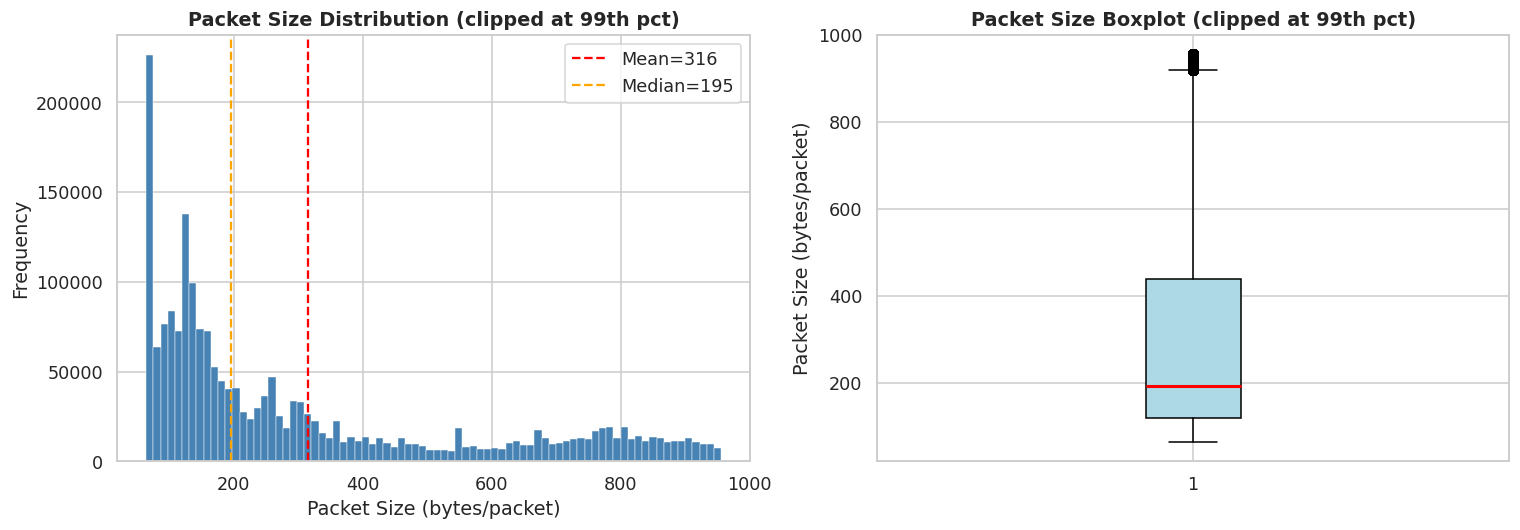

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clip_val = ps.quantile(0.99)
ps_c = ps[ps <= clip_val]

axes[0].hist(ps_c, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(mean_ps,   color='red',    linestyle='--', label=f'Mean={mean_ps:.0f}')
axes[0].axvline(median_ps, color='orange', linestyle='--', label=f'Median={median_ps:.0f}')
axes[0].set_xlabel('Packet Size (bytes/packet)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Packet Size Distribution (clipped at 99th pct)', fontweight='bold')
axes[0].legend()

axes[1].boxplot(ps_c, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Packet Size (bytes/packet)')
axes[1].set_title('Packet Size Boxplot (clipped at 99th pct)', fontweight='bold')
plt.tight_layout()
plt.savefig('1_4_packet_size.png', bbox_inches='tight')
plt.show()

### 1.5 — Top 3 Source–Destination Pairs

In [11]:
pair_counts = (
    df.groupby(['source', 'destination'])
      .agg(flow_count  = ('totalBytes',   'count'),
           total_bytes = ('totalBytes',   'sum'),
           protocols   = ('protocolName', lambda x: ', '.join(x.unique())),
           labels      = ('Label',        lambda x: ', '.join(x.unique())))
      .sort_values('flow_count', ascending=False)
      .head(TOP_PAIRS)
      .reset_index()
)
print(pair_counts[['source','destination','flow_count','total_bytes','protocols','labels']].to_string(index=False))

       source  destination  flow_count  total_bytes       protocols         labels
192.168.5.122 198.164.30.2      232409    129413679 udp_ip, icmp_ip Normal, Attack
192.168.2.107 125.6.164.51       58744    142974392          tcp_ip         Normal
192.168.3.115 203.73.24.75       43785    600719529          tcp_ip         Normal


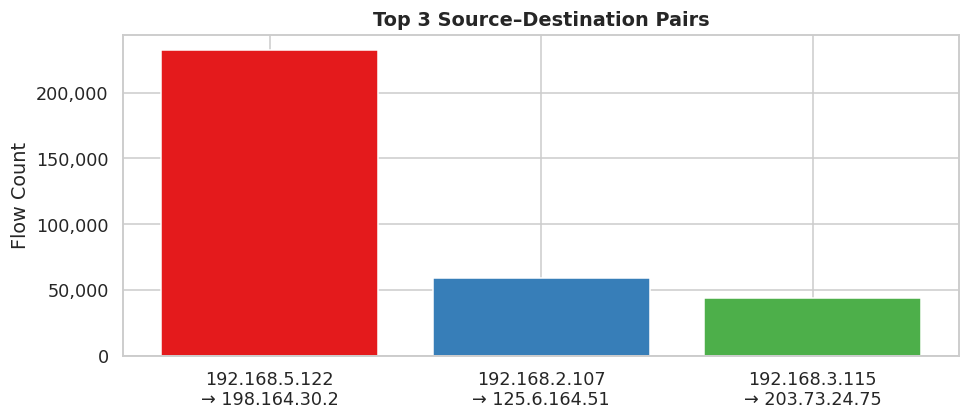

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
pair_labels = [f"{r.source}\n→ {r.destination}" for _, r in pair_counts.iterrows()]
ax.bar(pair_labels, pair_counts['flow_count'],
       color=sns.color_palette('Set1', TOP_PAIRS))
ax.set_ylabel('Flow Count')
ax.set_title(f'Top {TOP_PAIRS} Source–Destination Pairs', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('1_5_top_pairs.png', bbox_inches='tight')
plt.show()

### 1.6 — Consistent Communication Patterns

**Time window:** 1 hour — standard IDS baseline granularity that balances sensitivity and noise.  
An IP is flagged as a "consistent communicator" if it appears in at least 75% of all hourly windows. Internal servers, monitoring agents, or persistent attackers would show up here.

In [13]:
window_ip = (
    df_ts.groupby([pd.Grouper(freq=TIME_WINDOW), 'source'])
         .size().reset_index(name='flow_count')
)
window_ip.columns = ['window', 'source', 'flow_count']
total_windows = window_ip['window'].nunique()

ip_window_counts = (
    window_ip.groupby('source')['window'].nunique()
             .reset_index(name='windows_active')
)
ip_window_counts['fraction'] = ip_window_counts['windows_active'] / total_windows
consistent_ips = (
    ip_window_counts[ip_window_counts['fraction'] >= CONSISTENCY_THRESH]
    .sort_values('fraction', ascending=False)
)

print(f"Total {TIME_WINDOW} windows: {total_windows}")
print(f"IPs active in ≥{CONSISTENCY_THRESH*100:.0f}% of windows: {len(consistent_ips)}")
print(consistent_ips.head(20).to_string(index=False))

Total 1h windows: 146
IPs active in ≥75% of windows: 25
       source  windows_active  fraction
192.168.1.101             145  0.993151
192.168.2.106             145  0.993151
192.168.1.102             145  0.993151
192.168.1.103             145  0.993151
192.168.1.104             145  0.993151
192.168.2.107             145  0.993151
192.168.1.105             145  0.993151
192.168.2.109             145  0.993151
192.168.2.108             145  0.993151
192.168.3.116             145  0.993151
192.168.4.118             145  0.993151
192.168.2.110             145  0.993151
192.168.2.111             145  0.993151
192.168.2.112             145  0.993151
192.168.2.113             145  0.993151
192.168.3.114             145  0.993151
192.168.3.115             145  0.993151
192.168.5.122             145  0.993151
192.168.4.120             145  0.993151
192.168.4.119             145  0.993151


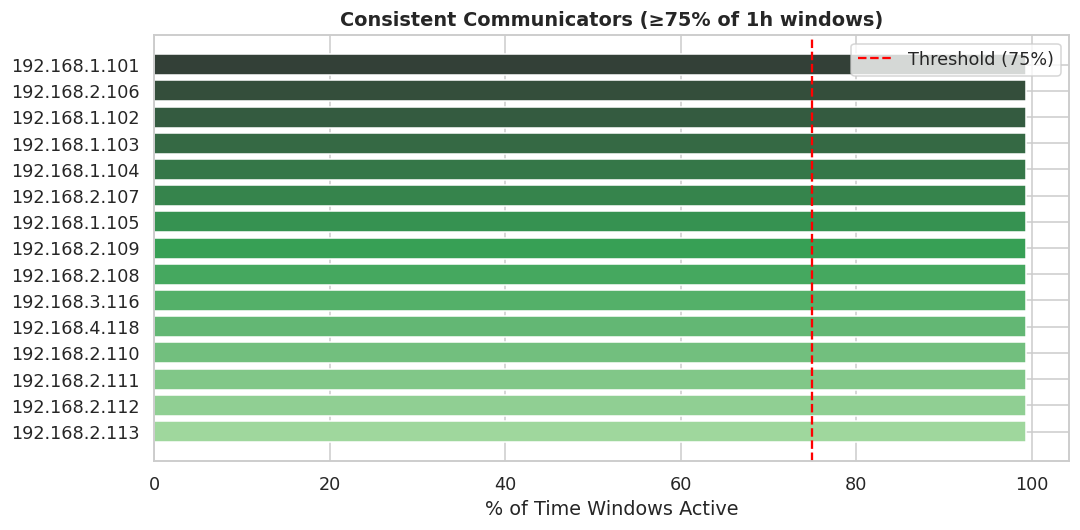

In [14]:
top_c = consistent_ips.head(15)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_c['source'][::-1], top_c['fraction'][::-1]*100,
        color=sns.color_palette('Greens_d', len(top_c)))
ax.axvline(CONSISTENCY_THRESH*100, color='red', linestyle='--',
           label=f'Threshold ({CONSISTENCY_THRESH*100:.0f}%)')
ax.set_xlabel('% of Time Windows Active')
ax.set_title(f'Consistent Communicators (≥{CONSISTENCY_THRESH*100:.0f}% of {TIME_WINDOW} windows)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('1_6_consistent_ips.png', bbox_inches='tight')
plt.show()

### 1.7 — Traffic Volume Spikes

**Spike definition:** any 5-minute interval where total bytes > mean + 3σ.  
The 3-sigma rule flags only ~0.3% of values under a normal distribution, so only genuinely extreme bursts are captured. Possible causes include DDoS attacks, port scans, large scheduled backups, or malware propagation.

In [15]:
traffic_ts = df_ts['totalBytes'].resample(RESAMPLE_FREQ).sum().fillna(0)
mean_vol   = traffic_ts.mean()
std_vol    = traffic_ts.std()
threshold  = mean_vol + SPIKE_SIGMA * std_vol
spikes     = traffic_ts[traffic_ts > threshold]

print(f"Intervals ({RESAMPLE_FREQ}): {len(traffic_ts)}")
print(f"Mean volume/interval : {mean_vol:>15,.0f} bytes")
print(f"Spike threshold      : {threshold:>15,.0f} bytes  (mean+{SPIKE_SIGMA}σ)")
print(f"Spike intervals      : {len(spikes)}")
if len(spikes) > 0:
    print("\nTop 10 spikes:")
    print(spikes.nlargest(10).apply(lambda x: f'{x:,}').rename('bytes').to_frame())

Intervals (5min): 1774
Mean volume/interval :      43,149,854 bytes
Spike threshold      :     301,827,214 bytes  (mean+3σ)
Spike intervals      : 25

Top 10 spikes:
                             bytes
startDateTime                     
2010-06-16 05:25:00  1,300,961,192
2010-06-17 08:55:00    867,202,971
2010-06-14 22:10:00    814,447,204
2010-06-15 02:10:00    802,608,437
2010-06-15 16:45:00    750,982,243
2010-06-15 16:55:00    710,162,479
2010-06-15 16:25:00    700,600,378
2010-06-15 16:30:00    697,784,640
2010-06-15 16:20:00    689,711,477
2010-06-15 16:05:00    688,151,670


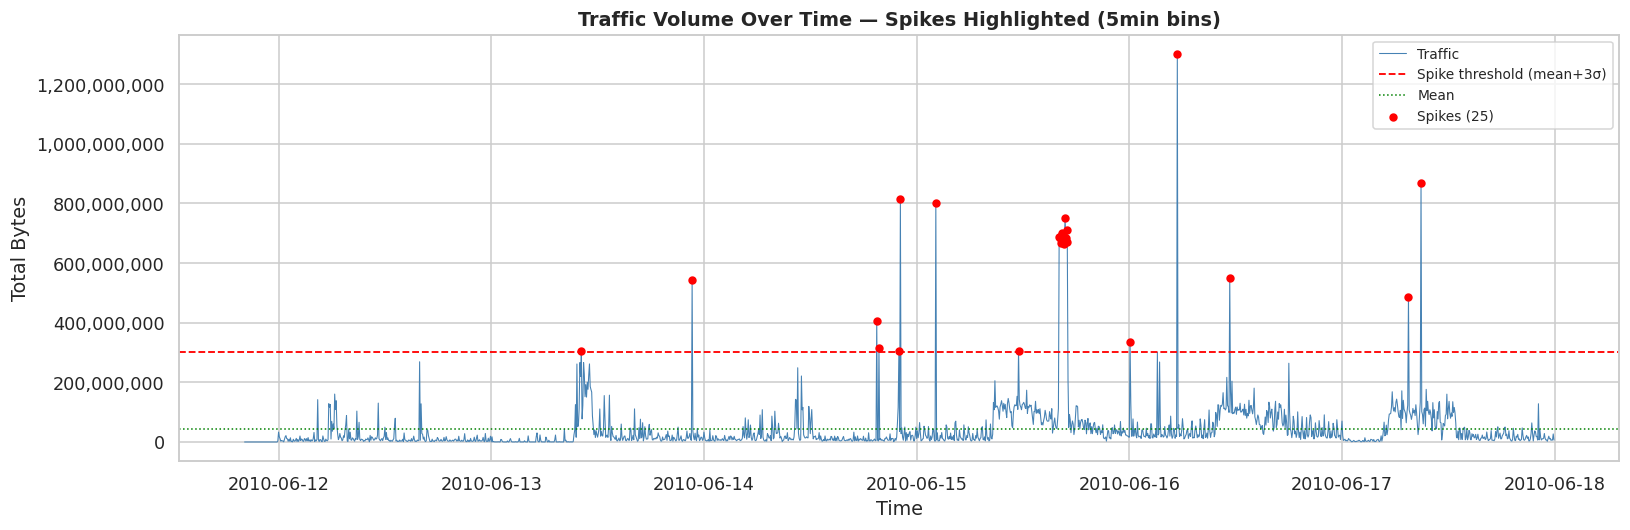

In [16]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(traffic_ts.index, traffic_ts.values, linewidth=0.7, color='steelblue', label='Traffic')
ax.axhline(threshold, color='red',   linestyle='--', linewidth=1.2, label=f'Spike threshold (mean+{SPIKE_SIGMA}σ)')
ax.axhline(mean_vol,  color='green', linestyle=':',  linewidth=1.0, label=f'Mean')
ax.scatter(spikes.index, spikes.values, color='red', s=20, zorder=5,
           label=f'Spikes ({len(spikes)})')
ax.set_xlabel('Time')
ax.set_ylabel('Total Bytes')
ax.set_title(f'Traffic Volume Over Time — Spikes Highlighted ({RESAMPLE_FREQ} bins)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('1_7_spikes.png', bbox_inches='tight')
plt.show()

### 1.8 — Packet Size Variance

High variance (CV > 1) in packet sizes is common in mixed enterprise traffic — a bimodal mix of small control packets (~64 bytes) and large data transfers (up to MTU). Per-protocol breakdown helps confirm whether high variance is expected or anomalous.

In [17]:
ps_clean = df['packetSize'].dropna()
variance = np.var(ps_clean, ddof=1)
std_dev  = np.std(ps_clean, ddof=1)
cv       = std_dev / ps_clean.mean()

print(f"Sample variance (σ²)     : {variance:>15,.2f}")
print(f"Standard deviation (σ)   : {std_dev:>15,.2f} bytes")
print(f"Coefficient of variation : {cv*100:.1f}%")
print(f"\nHigh variance? {'YES — heterogeneous traffic (expected)' if cv > 1.0 else 'NO — relatively homogeneous traffic'}")

print("\nVariance by protocol:")
print(df.dropna(subset=['packetSize'])
        .groupby('protocolName')['packetSize']
        .agg(['mean','std','var','count']).round(2)
        .sort_values('var', ascending=False).to_string())

# Global average: total bytes across all flows / total packets across all flows
# This gives higher weight to large flows — used in standard network engineering
global_avg = df['totalBytes'].sum() / df['totalPackets'].replace(0, np.nan).sum()
print(f"\nGlobal avg packet size : {global_avg:.2f} bytes  (total bytes / total packets)")
print(f"Per-flow avg           : {mean_ps:.2f} bytes  (mean of each flow's bytes/packet)")
print(f"Note: global avg is higher because large flows dominate the sum.")

Sample variance (σ²)     :       70,795.81
Standard deviation (σ)   :          266.07 bytes
Coefficient of variation : 84.3%

High variance? NO — relatively homogeneous traffic

Variance by protocol:
                mean     std       var    count
protocolName                                   
tcp_ip        350.00  286.28  81953.47  1644056
icmp_ip       123.11   80.74   6519.37     8211
udp_ip        185.48   77.50   6006.60   419246
ip             94.00    0.00      0.00       66
igmp           64.00    0.00      0.00       77
ipv6icmp       74.00     NaN       NaN        1

Global avg packet size : 736.92 bytes  (total bytes / total packets)
Per-flow avg           : 315.79 bytes  (mean of each flow's bytes/packet)
Note: global avg is higher because large flows dominate the sum.


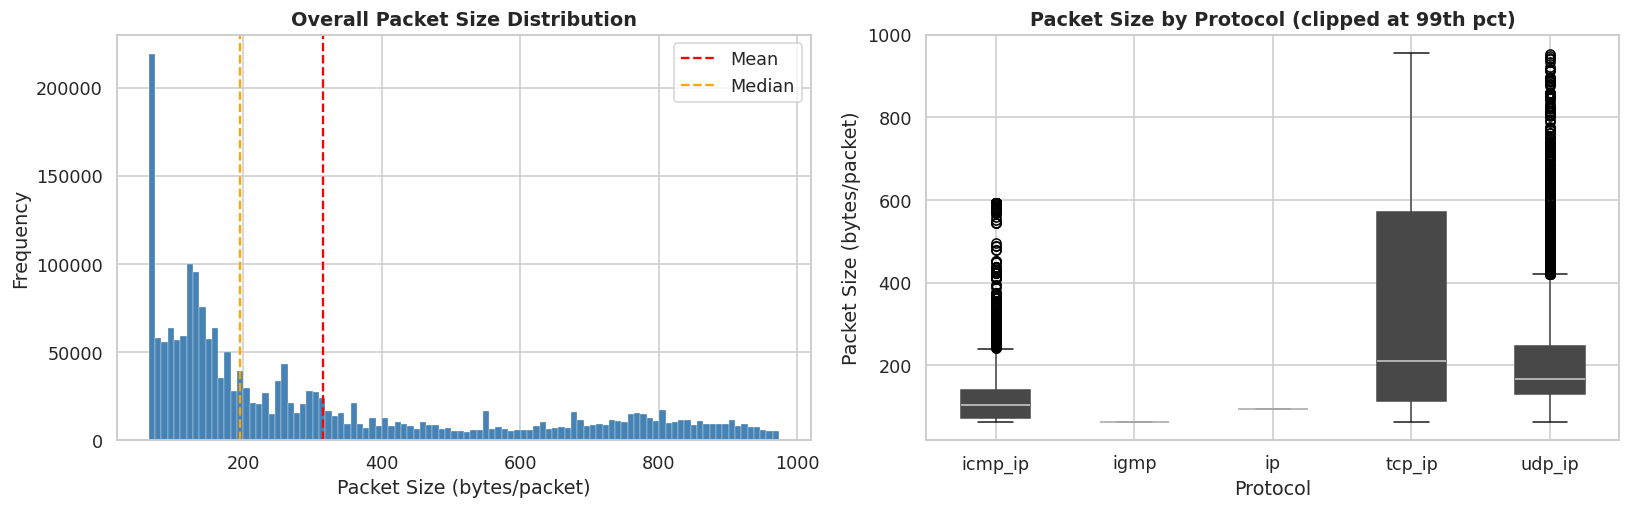

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ps_plot = ps_clean[ps_clean <= ps_clean.quantile(0.995)]

axes[0].hist(ps_plot, bins=100, color='steelblue', edgecolor='white', linewidth=0.2)
axes[0].axvline(ps_clean.mean(),   color='red',    linestyle='--', label='Mean')
axes[0].axvline(ps_clean.median(), color='orange', linestyle='--', label='Median')
axes[0].set_xlabel('Packet Size (bytes/packet)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Overall Packet Size Distribution', fontweight='bold')
axes[0].legend()

top5_proto = df['protocolName'].value_counts().head(5).index.tolist()
df_p = df[df['protocolName'].isin(top5_proto)].dropna(subset=['packetSize'])
df_p = df_p[df_p['packetSize'] <= df_p['packetSize'].quantile(0.99)]
df_p.boxplot(column='packetSize', by='protocolName', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('Protocol')
axes[1].set_ylabel('Packet Size (bytes/packet)')
axes[1].set_title('Packet Size by Protocol (clipped at 99th pct)', fontweight='bold')
plt.suptitle('')
plt.tight_layout()
plt.savefig('1_8_variance.png', bbox_inches='tight')
plt.show()

---
## Phase 2 — Traffic Estimation Using Sublinear Space

Real-world network monitoring systems can't store full per-IP state for all traffic. This phase implements three space-efficient (sublinear) algorithms and validates each against exact linear-space results:

- **2a — HyperLogLog**: estimate the number of unique IPs
- **2b — Count-Min Sketch**: identify heavy-hitter destination IPs
- **2c — Bloom Filter**: approximate membership testing for blocklists

### 2a — HyperLogLog: Unique IP Estimation

HyperLogLog estimates set cardinality in O(m) space regardless of input size. It hashes each element, tracks the maximum run of leading zeros per register bucket, and uses a harmonic mean to estimate cardinality. Expected error ≈ 1.04/√m.

In [19]:
class HyperLogLog:
    def __init__(self, b=10):
        self.b, self.m = b, 1 << b
        self.registers = [0] * self.m
        self.alpha = (0.673 if self.m==16 else 0.697 if self.m==32 else
                      0.709 if self.m==64 else 0.7213 / (1.0 + 1.079/self.m))

    def _hash(self, x):   return mmh3.hash(str(x), signed=False)
    def _lz(self, bits, max_b):
        if bits == 0: return max_b + 1
        c = 1
        while c <= max_b and not (bits >> (max_b-c)) & 1: c += 1
        return c

    def add(self, x):
        h = self._hash(x)
        idx = h >> (32 - self.b)
        rem = h & ((1 << (32 - self.b)) - 1)
        self.registers[idx] = max(self.registers[idx], self._lz(rem, 32-self.b))

    def estimate(self):
        harm = sum(2.0**(-r) for r in self.registers)
        E = self.alpha * self.m**2 / harm
        if E <= 2.5 * self.m:
            z = self.registers.count(0)
            if z > 0: E = self.m * math.log(self.m / z)
        elif E > (2**32) / 30:
            E = -(2**32) * math.log(1 - E / 2**32)
        return int(E)

    def memory_bytes(self): return self.m

print("HyperLogLog defined.")
print(f"  b=10 → m={1<<10} registers → ~{1.04/math.sqrt(1<<10)*100:.1f}% expected error")
print(f"  b=12 → m={1<<12} registers → ~{1.04/math.sqrt(1<<12)*100:.1f}% expected error")
print(f"  b=14 → m={1<<14} registers → ~{1.04/math.sqrt(1<<14)*100:.1f}% expected error")

HyperLogLog defined.
  b=10 → m=1024 registers → ~3.2% expected error
  b=12 → m=4096 registers → ~1.6% expected error
  b=14 → m=16384 registers → ~0.8% expected error


In [20]:
# Combine source and destination into a single stream of all IPs
all_ips = df['source'].tolist() + df['destination'].tolist()

# Exact count (linear space)
t0 = time.perf_counter()
exact_unique = len(set(all_ips))
exact_time   = time.perf_counter() - t0
exact_mem    = sys.getsizeof(set(all_ips))

print(f"Exact unique IPs : {exact_unique:,}  (time: {exact_time*1000:.1f}ms, mem: {exact_mem/1024:.1f}KB)")
print()

results_hll = []
for b in [8, 10, 12, 14]:
    hll = HyperLogLog(b=b)
    t0  = time.perf_counter()
    for ip in all_ips: hll.add(ip)
    t_hll = time.perf_counter() - t0
    est   = hll.estimate()
    err   = abs(est - exact_unique) / exact_unique * 100
    results_hll.append({
        'b': b, 'm': hll.m,
        'Expected error %': round(1.04/math.sqrt(hll.m)*100, 2),
        'HLL estimate': est, 'Actual error %': round(err, 2),
        'Memory (KB)': round(hll.memory_bytes()/1024, 3),
        'Time (ms)': round(t_hll*1000, 1),
        'Within 10%?': 'YES ✓' if err <= 10 else 'NO ✗'
    })
    print(f"  b={b}  m={hll.m:>6}  estimate={est:>8,}  error={err:>5.2f}%  "
          f"mem={hll.memory_bytes()/1024:.3f}KB  {'✓' if err<=10 else '✗'}")

print()
print(pd.DataFrame(results_hll)[['b','m','Expected error %','HLL estimate','Actual error %','Memory (KB)','Within 10%?']].to_string(index=False))

Exact unique IPs : 34,801  (time: 38.9ms, mem: 2048.2KB)

  b=8  m=   256  estimate=  31,840  error= 8.51%  mem=0.250KB  ✓
  b=10  m=  1024  estimate=  32,034  error= 7.95%  mem=1.000KB  ✓
  b=12  m=  4096  estimate=  34,236  error= 1.62%  mem=4.000KB  ✓
  b=14  m= 16384  estimate=  34,029  error= 2.22%  mem=16.000KB  ✓

 b     m  Expected error %  HLL estimate  Actual error %  Memory (KB) Within 10%?
 8   256              6.50         31840            8.51         0.25       YES ✓
10  1024              3.25         32034            7.95         1.00       YES ✓
12  4096              1.62         34236            1.62         4.00       YES ✓
14 16384              0.81         34029            2.22        16.00       YES ✓


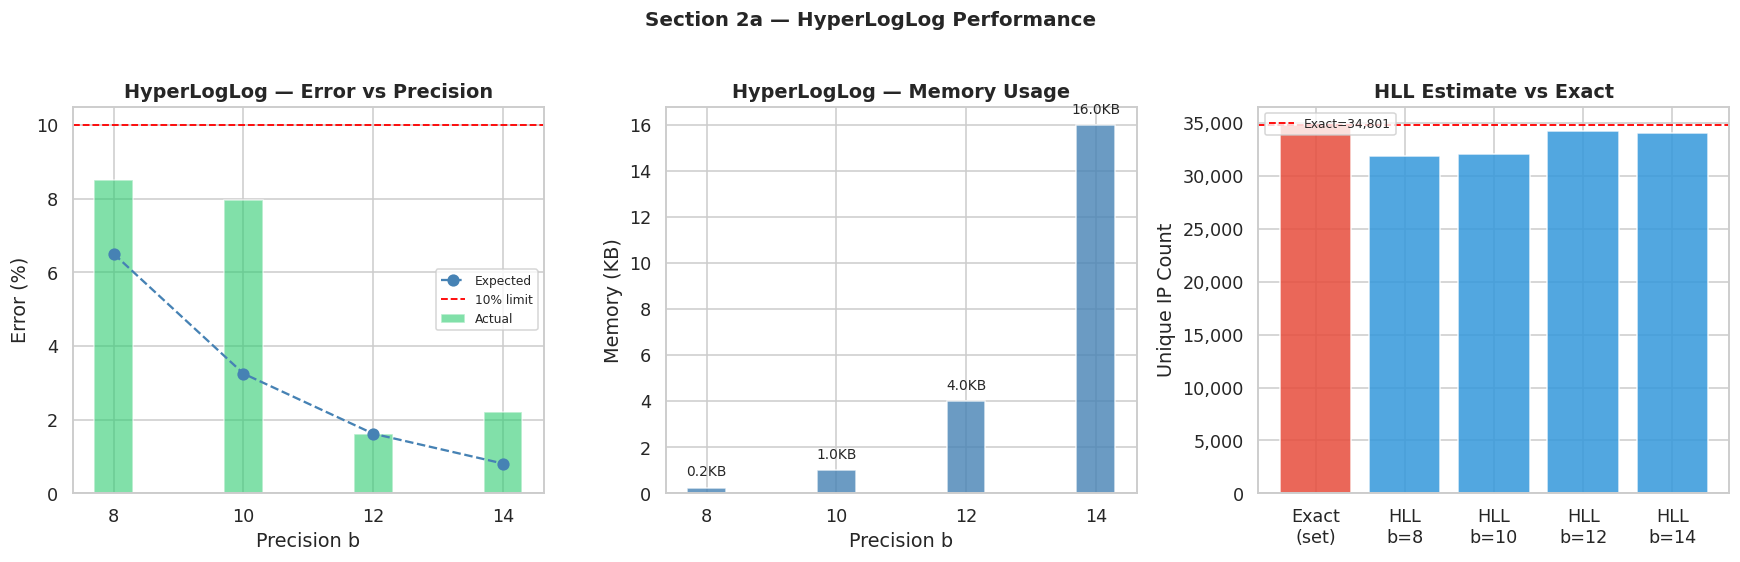

Trade-off summary:
  b=8  (m=256)  : lowest memory (0.25 KB), highest error
  b=10 (m=1024) : ~3.25% expected error, 1 KB — good balance
  b=12 (m=4096) : ~1.62% expected error, 4 KB — high accuracy
  b=14 (m=16384): ~0.81% expected error, 16 KB — near-exact
  Exact set used: 2048.2 KB vs HLL b=14: 16 KB


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
b_vals    = [r['b'] for r in results_hll]
errors    = [r['Actual error %'] for r in results_hll]
exp_errs  = [r['Expected error %'] for r in results_hll]
mem_vals  = [r['Memory (KB)'] for r in results_hll]
estimates = [r['HLL estimate'] for r in results_hll]
colors    = ['#e74c3c' if e > 10 else '#2ecc71' for e in errors]

axes[0].plot(b_vals, exp_errs, 'o--', color='steelblue', linewidth=1.5, markersize=7, label='Expected')
axes[0].bar(b_vals, errors, color=colors, alpha=0.6, width=0.6, label='Actual')
axes[0].axhline(10, color='red', linestyle='--', linewidth=1.2, label='10% limit')
axes[0].set_xlabel('Precision b'); axes[0].set_ylabel('Error (%)')
axes[0].set_title('HyperLogLog — Error vs Precision', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].set_xticks(b_vals)

axes[1].bar(b_vals, mem_vals, color='steelblue', alpha=0.8, width=0.6)
for b, m in zip(b_vals, mem_vals):
    axes[1].text(b, m+0.5, f'{m:.1f}KB', ha='center', fontsize=9)
axes[1].set_xlabel('Precision b'); axes[1].set_ylabel('Memory (KB)')
axes[1].set_title('HyperLogLog — Memory Usage', fontweight='bold'); axes[1].set_xticks(b_vals)

axes[2].bar(['Exact\n(set)'] + [f'HLL\nb={b}' for b in b_vals],
            [exact_unique] + estimates,
            color=['#e74c3c'] + ['#3498db']*len(b_vals), alpha=0.85)
axes[2].axhline(exact_unique, color='red', linestyle='--', linewidth=1.2, label=f'Exact={exact_unique:,}')
axes[2].set_ylabel('Unique IP Count')
axes[2].set_title('HLL Estimate vs Exact', fontweight='bold')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[2].legend(fontsize=8)

plt.suptitle('Section 2a — HyperLogLog Performance', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('2a_hyperloglog.png', bbox_inches='tight')
plt.show()

print("Trade-off summary:")
print("  b=8  (m=256)  : lowest memory (0.25 KB), highest error")
print("  b=10 (m=1024) : ~3.25% expected error, 1 KB — good balance")
print("  b=12 (m=4096) : ~1.62% expected error, 4 KB — high accuracy")
print("  b=14 (m=16384): ~0.81% expected error, 16 KB — near-exact")
print(f"  Exact set used: {exact_mem/1024:.1f} KB vs HLL b=14: 16 KB")

### 2b — Count-Min Sketch: Heavy Hitter Detection

Count-Min Sketch estimates element frequencies using a 2D counter array. For each element, d hash functions increment d counters; queries return the minimum across rows, which cancels out over-estimates from hash collisions. Error bound: ε·N per query with probability 1-(1/2)^d.

In [22]:
class CountMinSketch:
    def __init__(self, d=5, w=2000):
        self.d, self.w = d, w
        self.sketch = np.zeros((d, w), dtype=np.int64)
        self.total  = 0

    def add(self, x, count=1):
        self.total += count
        for j in range(self.d):
            self.sketch[j][mmh3.hash(str(x), seed=j, signed=False) % self.w] += count

    def estimate(self, x):
        return min(self.sketch[j][mmh3.hash(str(x), seed=j, signed=False) % self.w]
                   for j in range(self.d))

    def memory_bytes(self): return self.sketch.nbytes

print("CountMinSketch defined.")

CountMinSketch defined.


In [23]:
HEAVY_HITTER_THRESHOLD = 0.001  # dst IPs receiving > 0.1% of total flows

# Exact counts
t0 = time.perf_counter()
exact_dst  = df['destination'].value_counts().to_dict()
exact_time = time.perf_counter() - t0
exact_mem_cms = sys.getsizeof(exact_dst)
exact_heavy = {ip: c for ip, c in exact_dst.items() if c/total_flows >= HEAVY_HITTER_THRESHOLD}

print(f"Heavy hitter threshold   : {HEAVY_HITTER_THRESHOLD*100:.2f}% = {int(total_flows*HEAVY_HITTER_THRESHOLD):,} flows")
print(f"Exact heavy hitters      : {len(exact_heavy)}")
print(f"Exact method time/memory : {exact_time*1000:.1f}ms / {exact_mem_cms/1024:.1f}KB")
print()

cms_configs = [(3, 1000), (5, 2000), (7, 5000)]
cms_results = []
for d, w in cms_configs:
    cms = CountMinSketch(d=d, w=w)
    t0  = time.perf_counter()
    for ip in df['destination']: cms.add(ip)
    t_cms = time.perf_counter() - t0

    errs = [abs(cms.estimate(ip)-c)/c*100 for ip, c in exact_heavy.items()]
    detected = sum(1 for ip in exact_heavy if cms.estimate(ip)/total_flows >= HEAVY_HITTER_THRESHOLD)
    mean_err = np.mean(errs) if errs else 0

    cms_results.append({'d':d,'w':w,'cms':cms,'memory_kb':round(cms.memory_bytes()/1024,1),
        'mean_error_%':round(mean_err,3),'heavy_detected':detected,'within_10%':'YES ✓' if mean_err<=10 else 'NO ✗'})
    print(f"  d={d}, w={w:>5} | mem={cms.memory_bytes()/1024:.1f}KB | "
          f"mean_err={mean_err:.3f}% | detected={detected}/{len(exact_heavy)}")

best_cms = cms_results[1]['cms']  # d=5, w=2000
print(f"\nDetailed comparison (d=5, w=2000) — top 15 heavy hitters:")
print(f"  {'IP':<20} {'Exact':>10} {'CMS':>10} {'Error%':>8}")
for ip, c in sorted(exact_heavy.items(), key=lambda x: x[1], reverse=True)[:15]:
    est = best_cms.estimate(ip)
    print(f"  {ip:<20} {c:>10,} {est:>10,} {abs(est-c)/c*100:>7.3f}%")

Heavy hitter threshold   : 0.10% = 2,071 flows
Exact heavy hitters      : 101
Exact method time/memory : 144.7ms / 938.8KB

  d=3, w= 1000 | mem=23.4KB | mean_err=6.872% | detected=101/101
  d=5, w= 2000 | mem=78.1KB | mean_err=1.997% | detected=101/101
  d=7, w= 5000 | mem=273.4KB | mean_err=0.281% | detected=101/101

Detailed comparison (d=5, w=2000) — top 15 heavy hitters:
  IP                        Exact        CMS   Error%
  198.164.30.2            232,409    232,468   0.025%
  192.168.5.122           199,437    199,546   0.055%
  203.73.24.75            193,200    193,281   0.042%
  125.6.164.51            106,826    106,895   0.065%
  67.220.214.50            49,298     49,352   0.110%
  202.210.143.140          36,189     36,368   0.495%
  82.98.86.183             25,214     25,266   0.206%
  95.211.98.12             25,095     25,183   0.351%
  209.112.44.10            21,824     21,865   0.188%
  62.140.213.243           20,509     20,649   0.683%
  64.38.193.26             

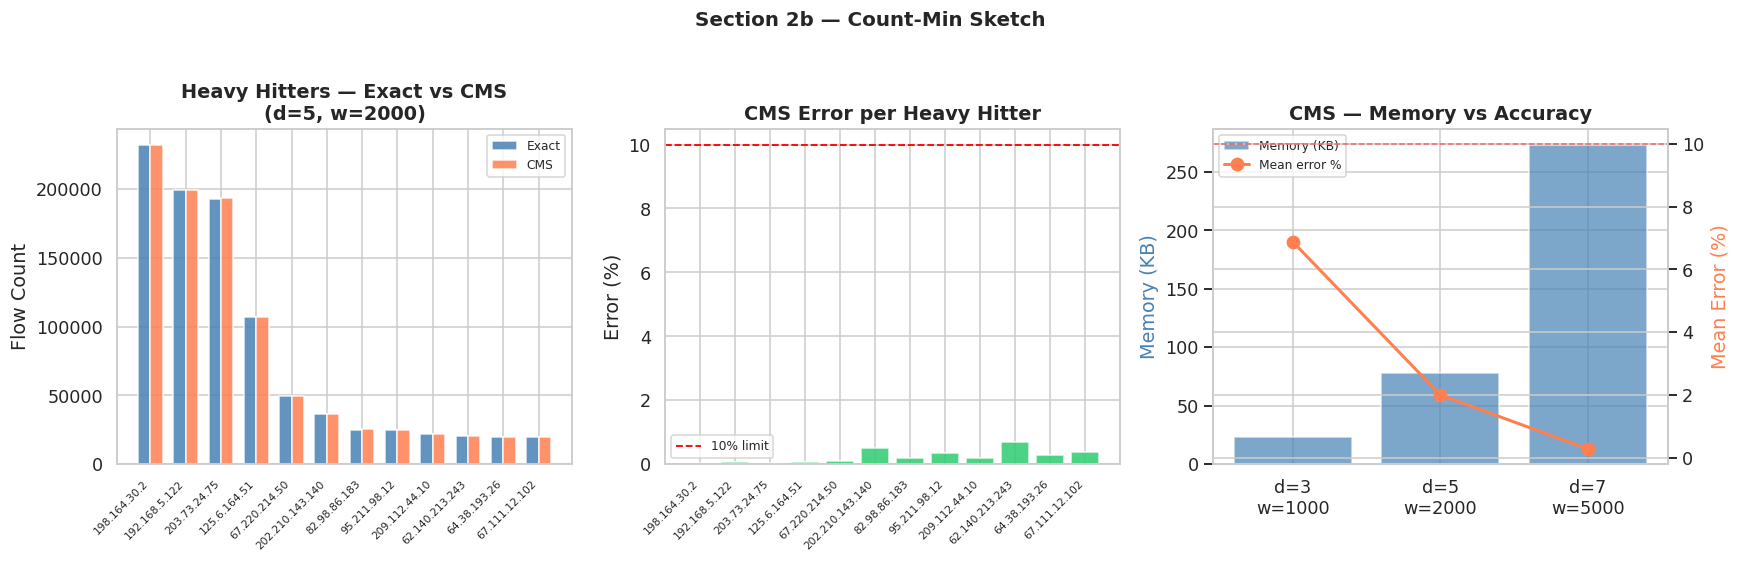

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

top_hh = sorted(exact_heavy.items(), key=lambda x: x[1], reverse=True)[:12]
hh_ips, exact_v, cms_v = [h[0] for h in top_hh], [h[1] for h in top_hh], [best_cms.estimate(h[0]) for h in top_hh]
x = np.arange(len(hh_ips)); w_bar = 0.35

axes[0].bar(x-w_bar/2, exact_v, w_bar, label='Exact', color='steelblue', alpha=0.85)
axes[0].bar(x+w_bar/2, cms_v,   w_bar, label='CMS',   color='coral',     alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(hh_ips, rotation=45, ha='right', fontsize=7)
axes[0].set_ylabel('Flow Count')
axes[0].set_title('Heavy Hitters — Exact vs CMS\n(d=5, w=2000)', fontweight='bold')
axes[0].legend(fontsize=8)

errs_per = [abs(best_cms.estimate(ip)-c)/c*100 for ip, c in top_hh]
ec = ['#2ecc71' if e<=10 else '#e74c3c' for e in errs_per]
axes[1].bar(range(len(hh_ips)), errs_per, color=ec, alpha=0.85)
axes[1].axhline(10, color='red', linestyle='--', linewidth=1.2, label='10% limit')
axes[1].set_xticks(range(len(hh_ips))); axes[1].set_xticklabels(hh_ips, rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('Error (%)'); axes[1].set_title('CMS Error per Heavy Hitter', fontweight='bold')
axes[1].legend(fontsize=8)

cfg_labels = [f"d={r['d']}\nw={r['w']}" for r in cms_results]
ax3b = axes[2].twinx()
axes[2].bar(cfg_labels, [r['memory_kb'] for r in cms_results], color='steelblue', alpha=0.7, label='Memory (KB)')
ax3b.plot(cfg_labels, [r['mean_error_%'] for r in cms_results], 'o-', color='coral', linewidth=2, markersize=8, label='Mean error %')
ax3b.axhline(10, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_ylabel('Memory (KB)', color='steelblue'); ax3b.set_ylabel('Mean Error (%)', color='coral')
axes[2].set_title('CMS — Memory vs Accuracy', fontweight='bold')
l1, lb1 = axes[2].get_legend_handles_labels(); l2, lb2 = ax3b.get_legend_handles_labels()
axes[2].legend(l1+l2, lb1+lb2, fontsize=8, loc='upper left')

plt.suptitle('Section 2b — Count-Min Sketch', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('2b_cms.png', bbox_inches='tight')
plt.show()

### 2c — Bloom Filter: Blocklist Membership Testing

A Bloom filter answers "has this IP been seen before?" using a fixed-size bit array and k hash functions. Insert: set k bits. Query: check all k bits. **Zero false negatives** — an inserted IP is always found. False positives are possible (uninserted IP may appear present), controlled by bit array size m and k.

In [25]:
class BloomFilter:
    def __init__(self, n_expected, fp_rate=0.01):
        self.n = n_expected; self.p = fp_rate
        self.m = int(-(n_expected * math.log(fp_rate)) / (math.log(2)**2)) + 1
        self.k = int((self.m / n_expected) * math.log(2)) + 1
        self.bits = bitarray(self.m); self.bits.setall(0)
        self.inserted = 0

    def add(self, x):
        for s in range(self.k):
            self.bits[mmh3.hash(str(x), seed=s, signed=False) % self.m] = 1
        self.inserted += 1

    def __contains__(self, x):
        return all(self.bits[mmh3.hash(str(x), seed=s, signed=False) % self.m]
                   for s in range(self.k))

    def theoretical_fp_rate(self):
        return (1 - math.exp(-self.k * self.inserted / self.m))**self.k if self.inserted else 0.0

    def memory_bytes(self): return self.m / 8

print("BloomFilter defined.")

BloomFilter defined.


In [26]:
import random; random.seed(42)
known_ips  = list(set(all_ips))
known_set  = set(known_ips)
n_known    = len(known_ips)
exact_set_mem = sys.getsizeof(known_set) / 1024

# Generate synthetic unseen IPs for false positive testing
def gen_unseen(known_set, n=5000):
    out = []
    while len(out) < n:
        ip = f"{random.randint(1,254)}.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(1,254)}"
        if ip not in known_set: out.append(ip)
    return out

unseen_ips = gen_unseen(known_set)
print(f"Blocklist size: {n_known:,} | Unseen IPs for FP test: {len(unseen_ips):,}")
print()

bf_results = []
for fp_rate in [0.05, 0.01, 0.001]:
    bf = BloomFilter(n_expected=n_known, fp_rate=fp_rate)
    t0 = time.perf_counter()
    for ip in known_ips: bf.add(ip)
    t_ins = time.perf_counter() - t0

    fn_count   = sum(1 for ip in known_ips if ip not in bf)
    fp_count   = sum(1 for ip in unseen_ips if ip in bf)
    actual_fpr = fp_count / len(unseen_ips) * 100
    theo_fpr   = bf.theoretical_fp_rate() * 100
    mem_kb     = bf.memory_bytes() / 1024

    bf_results.append({'Target FP %': fp_rate*100, 'Actual FP %': round(actual_fpr, 3),
        'Theoretical FP%': round(theo_fpr, 3), 'False negatives': fn_count,
        'm (bits)': bf.m, 'k (hashes)': bf.k,
        'Memory (KB)': round(mem_kb, 1), 'Exact set (KB)': round(exact_set_mem, 1)})
    print(f"  Target FP={fp_rate*100:.1f}% | Actual={actual_fpr:.3f}% (theory={theo_fpr:.3f}%) "
          f"| FN={fn_count} | mem={mem_kb:.1f}KB vs {exact_set_mem:.1f}KB exact | "
          f"saving={exact_set_mem/mem_kb:.1f}x")

print()
print(pd.DataFrame(bf_results)[['Target FP %','Actual FP %','Theoretical FP%','False negatives','Memory (KB)','Exact set (KB)']].to_string(index=False))

Blocklist size: 34,801 | Unseen IPs for FP test: 5,000

  Target FP=5.0% | Actual=4.480% (theory=5.103%) | FN=0 | mem=26.5KB vs 2048.2KB exact | saving=77.3x
  Target FP=1.0% | Actual=1.040% (theory=1.004%) | FN=0 | mem=40.7KB vs 2048.2KB exact | saving=50.3x
  Target FP=0.1% | Actual=0.100% (theory=0.100%) | FN=0 | mem=61.1KB vs 2048.2KB exact | saving=33.5x

 Target FP %  Actual FP %  Theoretical FP%  False negatives  Memory (KB)  Exact set (KB)
         5.0         4.48            5.103                0         26.5          2048.2
         1.0         1.04            1.004                0         40.7          2048.2
         0.1         0.10            0.100                0         61.1          2048.2


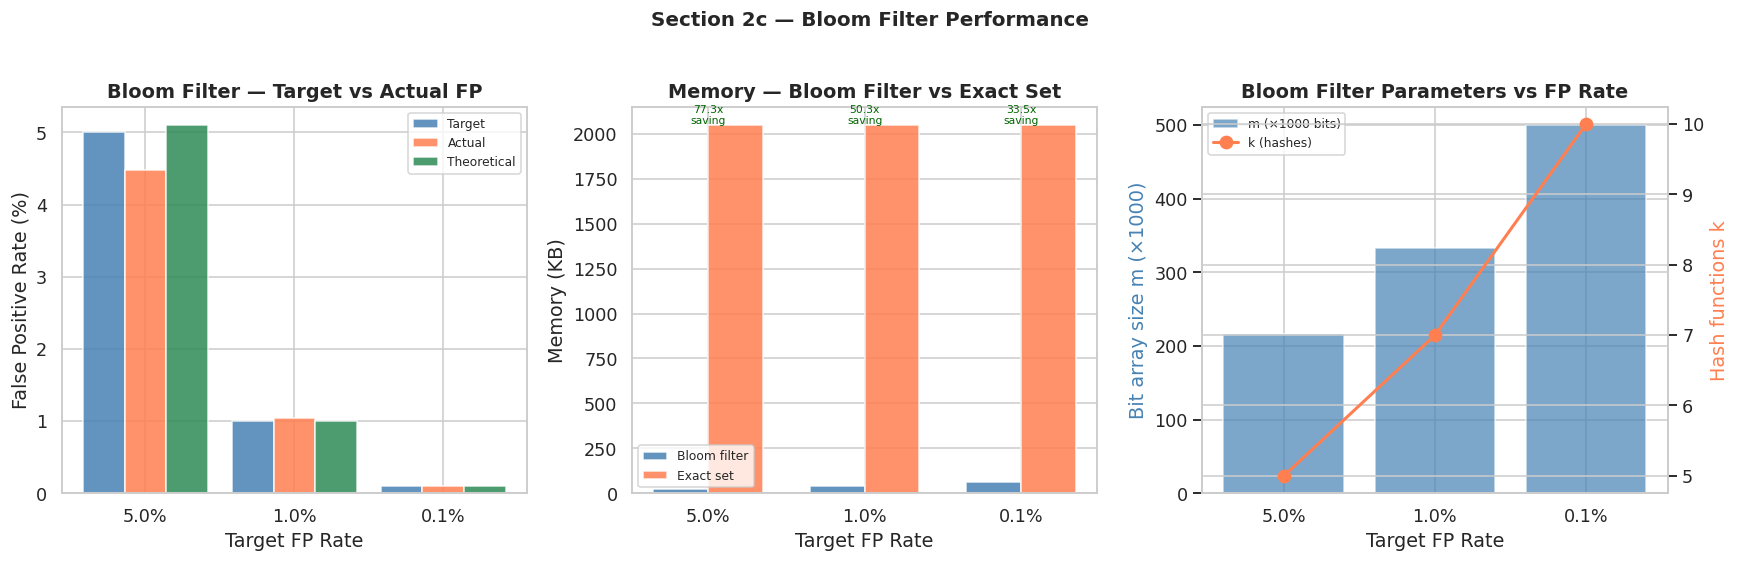

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
targets  = [r['Target FP %']     for r in bf_results]
actual   = [r['Actual FP %']     for r in bf_results]
theory   = [r['Theoretical FP%'] for r in bf_results]
mem_bf   = [r['Memory (KB)']     for r in bf_results]
mem_ex   = [r['Exact set (KB)']  for r in bf_results]
k_vals   = [r['k (hashes)']      for r in bf_results]
m_vals   = [r['m (bits)']        for r in bf_results]
x = np.arange(len(targets)); labels = [f'{t:.1f}%' for t in targets]
w2 = 0.28

axes[0].bar(x-w2, targets, w2, label='Target',      color='steelblue', alpha=0.85)
axes[0].bar(x,    actual,  w2, label='Actual',       color='coral',     alpha=0.85)
axes[0].bar(x+w2, theory,  w2, label='Theoretical',  color='seagreen',  alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_xlabel('Target FP Rate'); axes[0].set_ylabel('False Positive Rate (%)')
axes[0].set_title('Bloom Filter — Target vs Actual FP', fontweight='bold'); axes[0].legend(fontsize=8)

w3 = 0.35
axes[1].bar(x-w3/2, mem_bf, w3, label='Bloom filter', color='steelblue', alpha=0.85)
axes[1].bar(x+w3/2, mem_ex, w3, label='Exact set',    color='coral',     alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_xlabel('Target FP Rate'); axes[1].set_ylabel('Memory (KB)')
axes[1].set_title('Memory — Bloom Filter vs Exact Set', fontweight='bold'); axes[1].legend(fontsize=8)
for i, (bm, em) in enumerate(zip(mem_bf, mem_ex)):
    axes[1].text(i, max(bm,em)+5, f'{em/bm:.1f}x\nsaving', ha='center', fontsize=7, color='darkgreen')

ax3b = axes[2].twinx()
axes[2].bar(x, [m/1000 for m in m_vals], color='steelblue', alpha=0.7, label='m (×1000 bits)')
ax3b.plot(x, k_vals, 'o-', color='coral', linewidth=2, markersize=8, label='k (hashes)')
axes[2].set_xticks(x); axes[2].set_xticklabels(labels)
axes[2].set_xlabel('Target FP Rate')
axes[2].set_ylabel('Bit array size m (×1000)', color='steelblue')
ax3b.set_ylabel('Hash functions k', color='coral')
axes[2].set_title('Bloom Filter Parameters vs FP Rate', fontweight='bold')
l1,lb1=axes[2].get_legend_handles_labels(); l2,lb2=ax3b.get_legend_handles_labels()
axes[2].legend(l1+l2, lb1+lb2, fontsize=8, loc='upper left')

plt.suptitle('Section 2c — Bloom Filter Performance', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('2c_bloom_filter.png', bbox_inches='tight')
plt.show()

---
## Phase 3 — Advanced Anomaly Detection

Building on Phase 1 statistics, we now flag specific anomalous behaviours: unusual packet sizes, temporal protocol shifts, high-volume IPs, sudden behavioural spikes, fan-in attacks, long-duration connections, and multi-protocol usage patterns.

### 3a.1 — Statistical Anomalies in Packet Sizes

Flows where packet size falls outside mean ± 3σ are flagged. We also break these down by protocol to see which traffic types generate the most outliers.

In [28]:
ps_mean, ps_std = ps.mean(), ps.std()
upper = ps_mean + SPIKE_SIGMA * ps_std
lower = max(ps_mean - SPIKE_SIGMA * ps_std, 0)

df['ps_anomaly'] = (df['packetSize'] > upper) | (df['packetSize'] < lower)
ps_anom = df[df['ps_anomaly']].copy()

print(f"Upper threshold : {upper:.2f} bytes (mean + {SPIKE_SIGMA}σ)")
print(f"Lower threshold : {lower:.2f} bytes (mean - {SPIKE_SIGMA}σ, clamped at 0)")
print(f"Anomalous flows : {len(ps_anom):,}  ({ps_anom['is_attack'].mean()*100:.1f}% are attack flows)")

print("\nAnomalies by protocol:")
print(ps_anom.groupby('protocolName')
             .agg(count=('packetSize','count'),
                  mean_ps=('packetSize','mean'),
                  attack_pct=('is_attack',lambda x: x.mean()*100))
             .sort_values('count', ascending=False).round(2).to_string())

Upper threshold : 1114.01 bytes (mean + 3σ)
Lower threshold : 0.00 bytes (mean - 3σ, clamped at 0)
Anomalous flows : 48  (0.0% are attack flows)

Anomalies by protocol:
              count  mean_ps  attack_pct
protocolName                            
tcp_ip           25  1368.98         0.0
udp_ip           23  1563.36         0.0


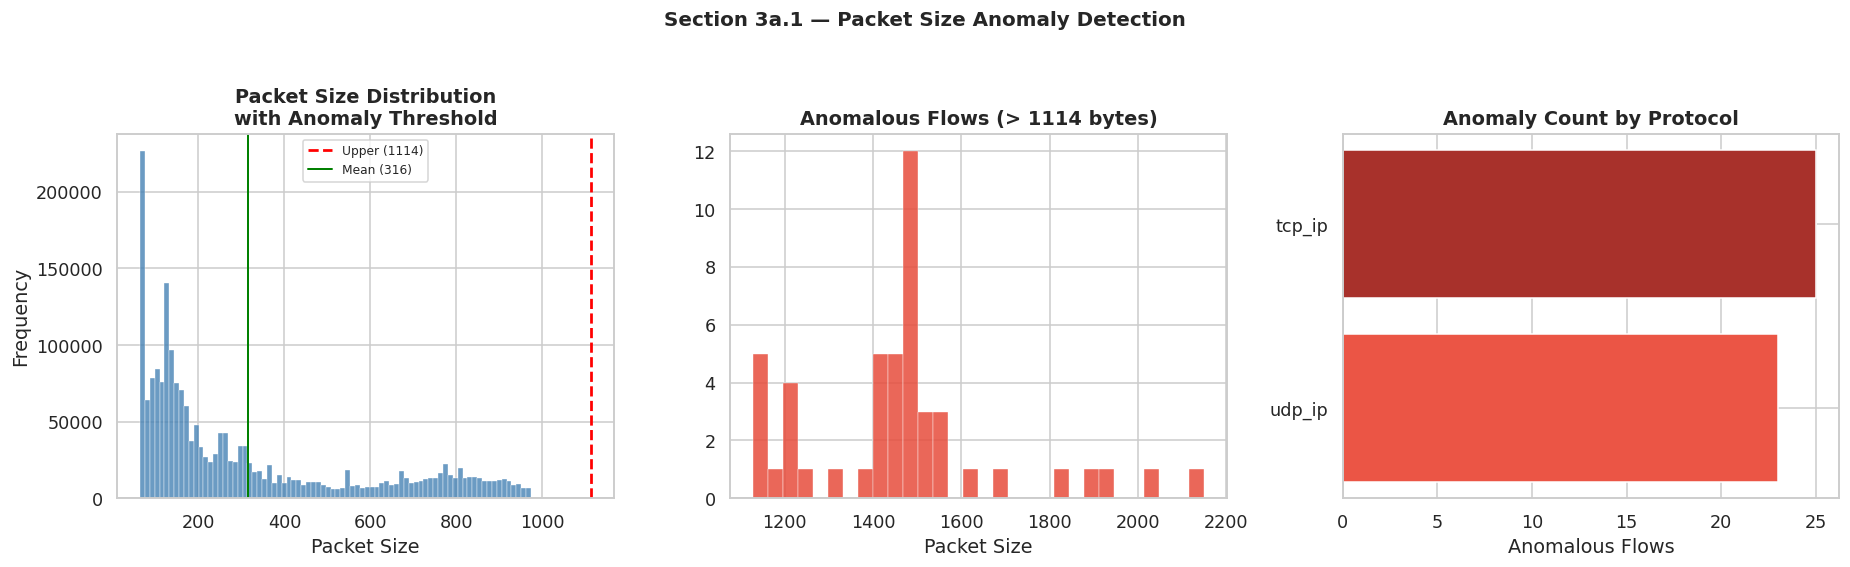

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ps_clip = ps[ps <= ps.quantile(0.995)]
axes[0].hist(ps_clip, bins=80, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.8)
axes[0].axvline(upper,   color='red',   linestyle='--', linewidth=1.8, label=f'Upper ({upper:.0f})')
axes[0].axvline(ps_mean, color='green', linestyle='-',  linewidth=1.3, label=f'Mean ({ps_mean:.0f})')
axes[0].set_xlabel('Packet Size'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Packet Size Distribution\nwith Anomaly Threshold', fontweight='bold')
axes[0].legend(fontsize=8)

ps_above = ps[ps > upper]
if len(ps_above) > 0:
    axes[1].hist(ps_above, bins=30, color='#e74c3c', edgecolor='white', linewidth=0.3, alpha=0.85)
    axes[1].set_xlabel('Packet Size'); axes[1].set_title(f'Anomalous Flows (> {upper:.0f} bytes)', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'No anomalies\nabove threshold', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=12, color='gray')
    axes[1].set_title('Anomalous Flows', fontweight='bold')

proto_anom_counts = df.groupby('protocolName')['ps_anomaly'].sum().sort_values(ascending=False)
proto_anom_counts = proto_anom_counts[proto_anom_counts > 0]
if len(proto_anom_counts) > 0:
    axes[2].barh(proto_anom_counts.index[::-1], proto_anom_counts.values[::-1],
                 color=sns.color_palette('Reds_d', len(proto_anom_counts)))
    axes[2].set_xlabel('Anomalous Flows')
    axes[2].set_title('Anomaly Count by Protocol', fontweight='bold')

plt.suptitle('Section 3a.1 — Packet Size Anomaly Detection', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('3a1_packet_anomalies.png', bbox_inches='tight')
plt.show()

### 3a.2 — Hourly vs Daily Traffic Patterns

We resample to hourly and daily granularities and run a chi-squared test on protocol distributions per hour against the overall baseline. A p-value < 0.05 means the protocol mix in that window is significantly different from normal.

In [30]:
hourly = df_ts['totalBytes'].resample('1h').sum()
daily  = df_ts['totalBytes'].resample('1D').sum()

baseline_proto = df['protocolName'].value_counts(normalize=True)
chi2_results = []
for period, group in df_ts.groupby(pd.Grouper(freq='1h')):
    if len(group) < 50: continue
    obs = group['protocolName'].value_counts().reindex(baseline_proto.index, fill_value=0)
    exp = baseline_proto * len(group)
    chi2, p = stats.chisquare(obs.values, f_exp=exp.values)
    chi2_results.append({'window': period, 'chi2': chi2, 'p_value': p,
                          'n_flows': len(group), 'anomalous': p < 0.05})

df_chi2 = pd.DataFrame(chi2_results)
anomalous_windows = df_chi2[df_chi2['anomalous']]
print(f"Hourly windows tested     : {len(df_chi2)}")
print(f"Anomalous windows (p<0.05): {len(anomalous_windows)}  ({len(anomalous_windows)/len(df_chi2)*100:.1f}%)")
print("\nTop anomalous windows by chi2 statistic:")
print(anomalous_windows.nlargest(10,'chi2')[['window','chi2','p_value','n_flows']].to_string(index=False))

Hourly windows tested     : 145
Anomalous windows (p<0.05): 145  (100.0%)

Top anomalous windows by chi2 statistic:
             window         chi2  p_value  n_flows
2010-06-15 02:00:00 24398.008983      0.0    16680
2010-06-15 04:00:00 16941.040139      0.0    17547
2010-06-15 07:00:00 15680.897879      0.0    18386
2010-06-15 05:00:00 15667.139636      0.0    16773
2010-06-15 06:00:00 14874.343501      0.0    16612
2010-06-15 03:00:00 13796.243530      0.0    14251
2010-06-14 22:00:00 10646.980426      0.0     7023
2010-06-15 16:00:00  9917.435540      0.0    63821
2010-06-15 01:00:00  8179.478938      0.0     9859
2010-06-14 23:00:00  7675.162237      0.0     5793


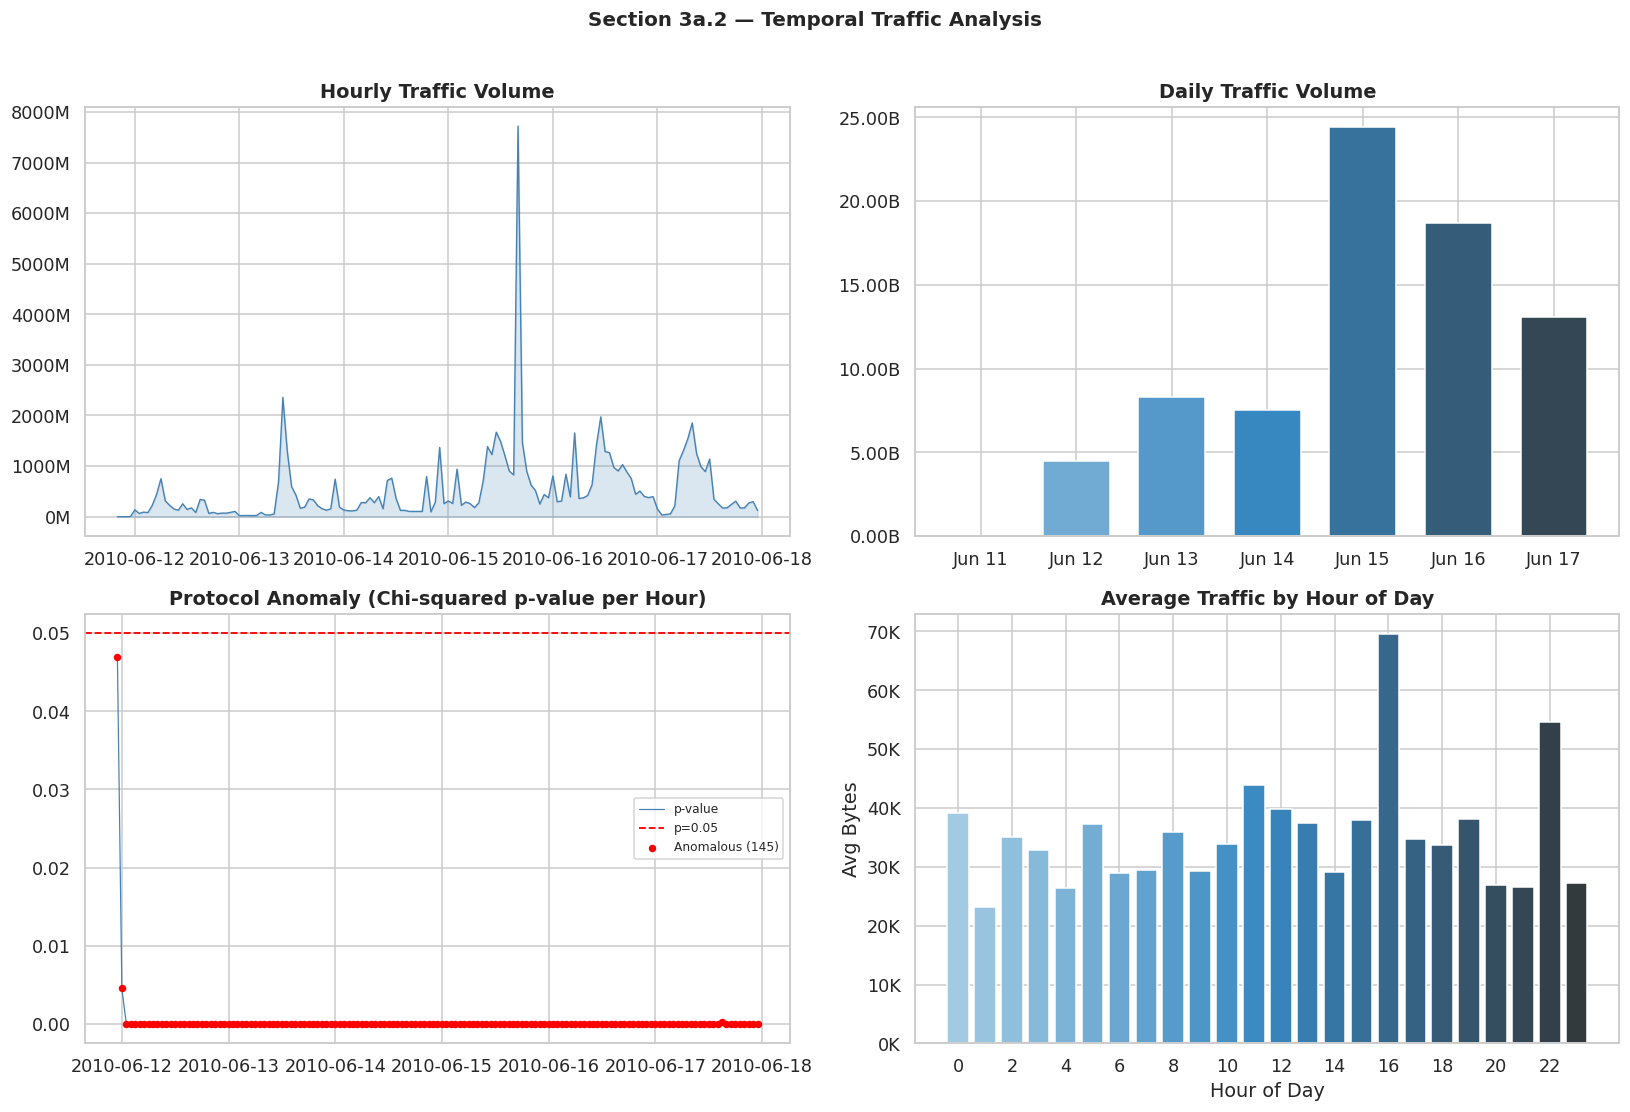

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].plot(hourly.index, hourly.values, linewidth=0.9, color='steelblue')
axes[0,0].fill_between(hourly.index, hourly.values, alpha=0.2, color='steelblue')
axes[0,0].set_title('Hourly Traffic Volume', fontweight='bold')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

axes[0,1].bar(daily.index, daily.values, color=sns.color_palette('Blues_d', len(daily)), width=0.7)
axes[0,1].set_title('Daily Traffic Volume', fontweight='bold')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.2f}B'))
axes[0,1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))

axes[1,0].plot(df_chi2['window'], df_chi2['p_value'], linewidth=0.8, color='steelblue', label='p-value')
axes[1,0].axhline(0.05, color='red', linestyle='--', linewidth=1.2, label='p=0.05')
axes[1,0].scatter(anomalous_windows['window'], anomalous_windows['p_value'],
                  color='red', s=15, zorder=5, label=f'Anomalous ({len(anomalous_windows)})')
axes[1,0].set_title('Protocol Anomaly (Chi-squared p-value per Hour)', fontweight='bold')
axes[1,0].legend(fontsize=8)

hourly_avg = df.groupby('hour_of_day')['totalBytes'].mean()
axes[1,1].bar(hourly_avg.index, hourly_avg.values, color=sns.color_palette('Blues_d', 24))
axes[1,1].set_xlabel('Hour of Day'); axes[1,1].set_ylabel('Avg Bytes')
axes[1,1].set_title('Average Traffic by Hour of Day', fontweight='bold')
axes[1,1].set_xticks(range(0, 24, 2))
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.suptitle('Section 3a.2 — Temporal Traffic Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('3a2_temporal.png', bbox_inches='tight')
plt.show()

### 3a.3 — Anomalous Traffic Volume IPs

Source IPs in the top 1% by flow count are flagged as high-volume. We also note the attack percentage for each, which helps distinguish legitimate heavy hitters (servers) from potential attackers.

In [32]:
src_stats = (
    df.groupby('source')
      .agg(flow_count   = ('totalBytes',      'count'),
           total_bytes  = ('totalBytes',      'sum'),
           attack_pct   = ('is_attack',       lambda x: round(x.mean()*100, 2)),
           unique_dests = ('destination',     'nunique'),
           unique_ports = ('destinationPort', 'nunique'))
      .reset_index()
)

high_thresh = src_stats['flow_count'].quantile(0.99)
low_thresh  = src_stats['flow_count'].quantile(0.01)
high_vol = src_stats[src_stats['flow_count'] >= high_thresh].sort_values('flow_count', ascending=False)
low_vol  = src_stats[src_stats['flow_count'] <= low_thresh].sort_values('flow_count')

print(f"High-volume threshold (99th pct): {high_thresh:,.0f} flows")
print(f"High-volume IPs: {len(high_vol)}")
print(high_vol[['source','flow_count','total_bytes','unique_dests','unique_ports','attack_pct']].to_string(index=False))

High-volume threshold (99th pct): 2,028 flows
High-volume IPs: 25
        source  flow_count  total_bytes  unique_dests  unique_ports  attack_pct
 192.168.5.122      268267    156360458           982            32        0.01
 192.168.2.107      208379   4861094682         23744         16961        0.00
 192.168.4.118      135374   4006130354          1927           647        3.88
 192.168.1.101      116292   6353065591          2128           235        0.42
 192.168.4.121      105454   3749783991          2138          3668        0.02
 192.168.1.105      101359   3458033524          1979          1610       20.06
 192.168.2.109       99183   7369281030          1620           101        0.02
 192.168.3.116       97241   2346423667          1695           243        0.00
 192.168.2.110       90658   3642212173          1695           275        9.38
 192.168.3.115       88915   3628934624          1422           299        0.77
 192.168.2.112       88301   5759816514          1849 

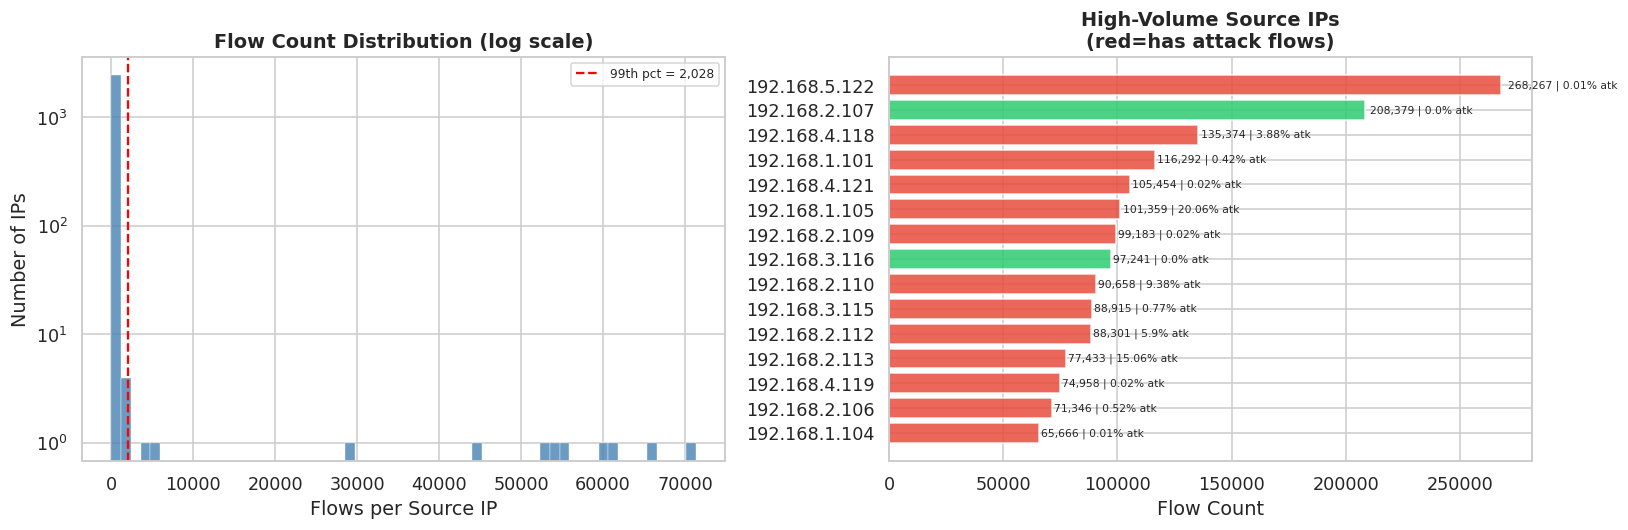

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fc_clip = src_stats['flow_count']
fc_clip = fc_clip[fc_clip <= fc_clip.quantile(0.995)]
axes[0].hist(fc_clip, bins=60, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.8)
axes[0].axvline(high_thresh, color='red', linestyle='--', linewidth=1.5,
                label=f'99th pct = {high_thresh:,.0f}')
axes[0].set_xlabel('Flows per Source IP'); axes[0].set_ylabel('Number of IPs')
axes[0].set_title('Flow Count Distribution (log scale)', fontweight='bold')
axes[0].set_yscale('log'); axes[0].legend(fontsize=8)

top_hv = high_vol.head(15)
bc = ['#e74c3c' if p > 0 else '#2ecc71' for p in top_hv['attack_pct']]
axes[1].barh(top_hv['source'][::-1], top_hv['flow_count'][::-1], color=bc[::-1], alpha=0.85)
axes[1].set_xlabel('Flow Count')
axes[1].set_title('High-Volume Source IPs\n(red=has attack flows)', fontweight='bold')
for i, (_, row) in enumerate(top_hv[::-1].iterrows()):
    axes[1].text(row['flow_count']*1.01, i, f"{row['flow_count']:,} | {row['attack_pct']}% atk",
                 va='center', fontsize=7)
plt.tight_layout()
plt.savefig('3a3_volume_anomalies.png', bbox_inches='tight')
plt.show()

### 3a.4 — Isolation Forest: Multi-Dimensional Anomaly Detection

Isolation Forest isolates anomalies by randomly partitioning the feature space. Points that require fewer splits to isolate are anomalies. We build a per-IP feature matrix (flow count, bytes, packet diversity, port count, protocol count) and flag the top 5% as anomalous.

In [34]:
ip_features = (
    df.groupby('source')
      .agg(flow_count      = ('totalBytes',      'count'),
           total_bytes     = ('totalBytes',      'sum'),
           mean_bytes      = ('totalBytes',      'mean'),
           mean_packets    = ('totalPackets',    'mean'),
           mean_packetsize = ('packetSize',      'mean'),
           unique_dsts     = ('destination',     'nunique'),
           unique_ports    = ('destinationPort', 'nunique'),
           n_protocols     = ('protocolName',    'nunique'))
      .reset_index().fillna(0)
)

FEATURES = ['flow_count','total_bytes','mean_bytes','mean_packets',
            'mean_packetsize','unique_dsts','unique_ports','n_protocols']
X = StandardScaler().fit_transform(ip_features[FEATURES])

iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
ip_features['iso_label'] = iso.fit_predict(X)   # -1 = anomaly
ip_features['iso_score'] = iso.decision_function(X)

iso_flagged  = ip_features[ip_features['iso_label'] == -1].sort_values('iso_score')
zscore_ips   = set(ip_features[ip_features['flow_count'] > FLOW_VOL_THRESHOLD]['source'])
iso_only_ips = set(iso_flagged['source']) - zscore_ips

print(f"IPs flagged by Z-score (volume)   : {len(zscore_ips)}")
print(f"IPs flagged by Isolation Forest   : {len(iso_flagged)}")
print(f"Flagged by ISO only (missed by Z) : {len(iso_only_ips)}")
print("\nTop 10 most anomalous IPs:")
print(iso_flagged[['source','flow_count','total_bytes','mean_packetsize',
                    'unique_ports','n_protocols','iso_score']].head(10).round(3).to_string(index=False))

IPs flagged by Z-score (volume)   : 25
IPs flagged by Isolation Forest   : 124
Flagged by ISO only (missed by Z) : 99

Top 10 most anomalous IPs:
       source  flow_count  total_bytes  mean_packetsize  unique_ports  n_protocols  iso_score
192.168.2.107      208379   4861094682          214.319         16961            4     -0.370
192.168.1.101      116292   6353065591          402.786           235            3     -0.366
192.168.2.112       88301   5759816514          339.674          1150            3     -0.366
192.168.4.121      105454   3749783991          345.013          3668            3     -0.360
192.168.4.120       53659   3331808952          408.265           283            3     -0.358
192.168.1.103       60189   5392234742          413.409           202            2     -0.357
192.168.2.113       77433   4811521438          381.820           572            2     -0.355
192.168.2.109       99183   7369281030          359.208           101            2     -0.355
192.168.

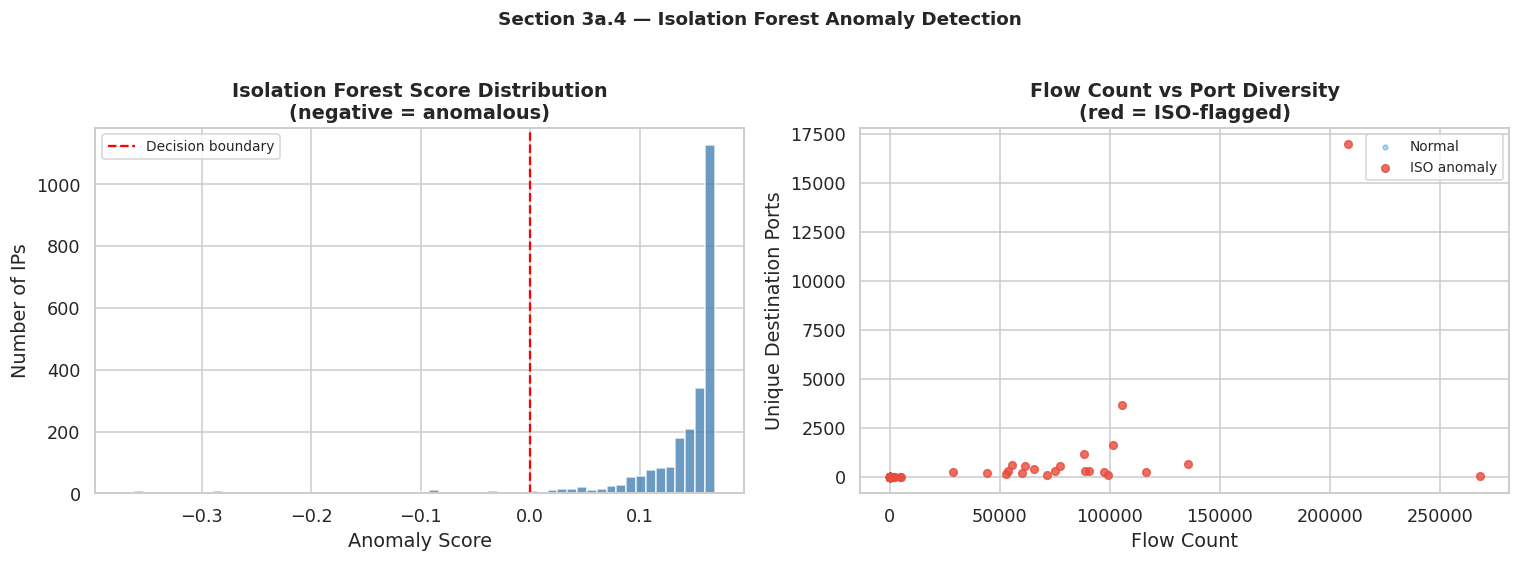

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ip_features['iso_score'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Decision boundary')
axes[0].set_xlabel('Anomaly Score'); axes[0].set_ylabel('Number of IPs')
axes[0].set_title('Isolation Forest Score Distribution\n(negative = anomalous)', fontweight='bold')
axes[0].legend(fontsize=9)

norm = ip_features[ip_features['iso_label'] ==  1]
anom = ip_features[ip_features['iso_label'] == -1]
axes[1].scatter(norm['flow_count'], norm['unique_ports'], c='#3498db', alpha=0.4, s=10, label='Normal')
axes[1].scatter(anom['flow_count'], anom['unique_ports'], c='#e74c3c', alpha=0.8, s=25, label='ISO anomaly')
axes[1].set_xlabel('Flow Count'); axes[1].set_ylabel('Unique Destination Ports')
axes[1].set_title('Flow Count vs Port Diversity\n(red = ISO-flagged)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Section 3a.4 — Isolation Forest Anomaly Detection', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('3a4_isolation_forest.png', bbox_inches='tight')
plt.show()

### 3b.1 — Behavioural Change Detection

For each IP, we compute hourly flow counts and flag windows where the current count exceeds 5× the 3-hour rolling mean. This catches sudden bursts from previously quiet hosts — a common signature of compromised machines starting a scan or attack.

In [36]:
ip_hourly = (
    df_ts.groupby([pd.Grouper(freq='1h'), 'source'])
         .size().reset_index(name='flow_count')
)
ip_hourly.columns = ['window', 'source', 'flow_count']
ip_hourly = ip_hourly.sort_values(['source', 'window'])

ip_hourly['rolling_mean'] = (
    ip_hourly.groupby('source')['flow_count']
             .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)
ip_hourly['spike_ratio']    = ip_hourly['flow_count'] / ip_hourly['rolling_mean'].replace(0, np.nan)
SPIKE_RATIO                 = 5
ip_hourly['behaviour_spike'] = (ip_hourly['spike_ratio'] > SPIKE_RATIO) & (ip_hourly['rolling_mean'] > 0)

spikes_df = ip_hourly[ip_hourly['behaviour_spike']].sort_values('spike_ratio', ascending=False)
print(f"Spike ratio threshold  : {SPIKE_RATIO}x rolling mean")
print(f"Total behaviour spikes : {len(spikes_df)}")
print(f"Unique IPs with spikes : {spikes_df['source'].nunique()}")
print("\nTop 15 largest spikes:")
print(spikes_df[['source','window','flow_count','rolling_mean','spike_ratio']].head(15).to_string(index=False))

Spike ratio threshold  : 5x rolling mean
Total behaviour spikes : 178
Unique IPs with spikes : 37

Top 15 largest spikes:
         source              window  flow_count  rolling_mean  spike_ratio
 131.202.243.90 2010-06-17 14:00:00        5116      3.666667  1395.272727
  192.168.2.110 2010-06-13 10:00:00       11370     38.666667   294.051724
  192.168.2.110 2010-06-17 05:00:00        3267     18.666667   175.017857
131.202.240.209 2010-06-14 16:00:00         491      4.000000   122.750000
  192.168.3.116 2010-06-17 05:00:00        6990     60.333333   115.856354
  192.168.2.107 2010-06-17 05:00:00        2889     27.666667   104.421687
  192.168.2.106 2010-06-13 09:00:00        5664     64.666667    87.587629
  192.168.3.115 2010-06-15 00:00:00        1021     12.333333    82.783784
  192.168.2.110 2010-06-12 00:00:00        1685     21.000000    80.238095
  192.168.4.120 2010-06-12 00:00:00         616      8.000000    77.000000
  192.168.2.107 2010-06-14 21:00:00        1081     1

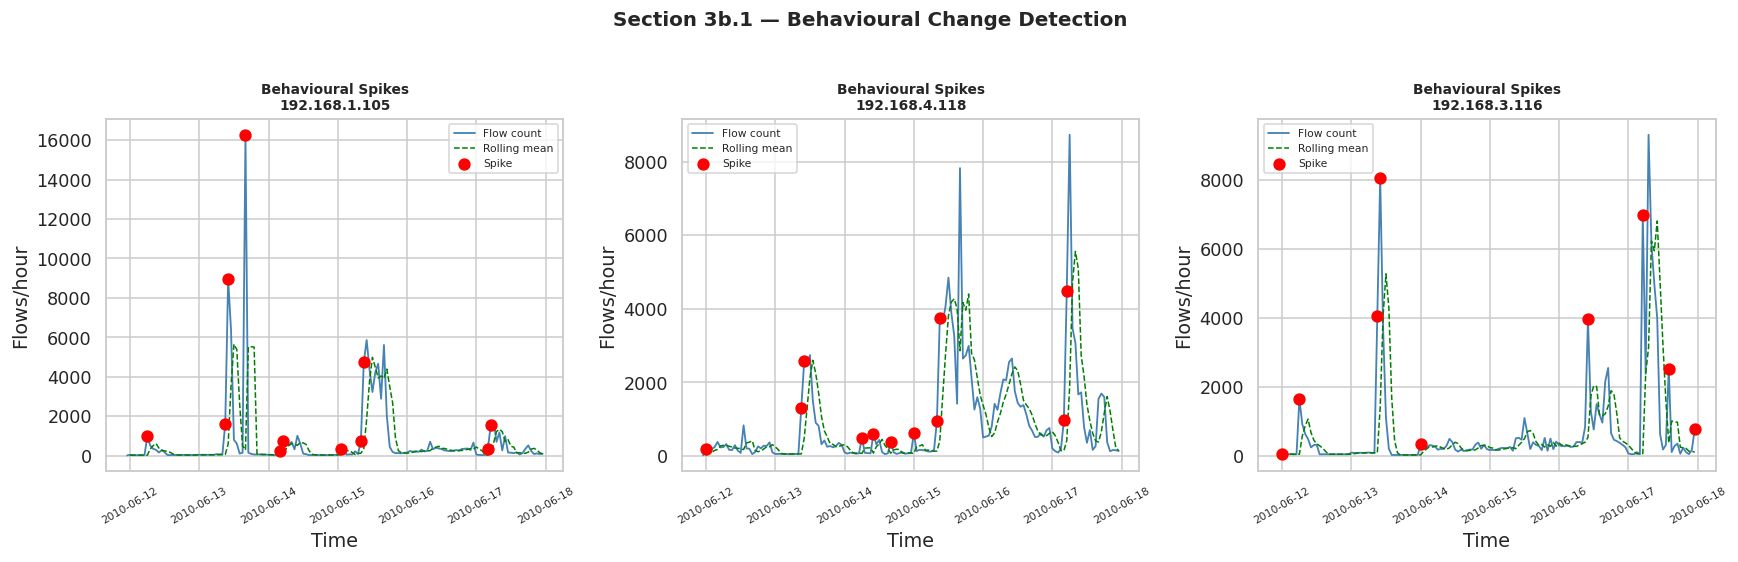

In [37]:
top_spike_ips = spikes_df['source'].value_counts().head(3).index.tolist()
fig, axes = plt.subplots(1, len(top_spike_ips), figsize=(16, 5), sharey=False)
if len(top_spike_ips) == 1: axes = [axes]

for ax, ip in zip(axes, top_spike_ips):
    ip_data   = ip_hourly[ip_hourly['source'] == ip]
    spike_pts = ip_data[ip_data['behaviour_spike']]
    ax.plot(ip_data['window'], ip_data['flow_count'], linewidth=1.2, color='steelblue', label='Flow count')
    ax.plot(ip_data['window'], ip_data['rolling_mean'], linewidth=1, color='green', linestyle='--', label='Rolling mean')
    ax.scatter(spike_pts['window'], spike_pts['flow_count'], color='red', s=50, zorder=5, label='Spike')
    ax.set_title(f'Behavioural Spikes\n{ip}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Time'); ax.set_ylabel('Flows/hour')
    ax.legend(fontsize=7); ax.tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Section 3b.1 — Behavioural Change Detection', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('3b1_behaviour_spikes.png', bbox_inches='tight')
plt.show()

### 3b.2 & 3b.3 — Fan-in and Coordinated Attack Detection

For each (hour, destination) pair we count distinct source IPs. A high fan-in count suggests coordinated activity — multiple hosts attacking the same target in a short window. This is a key DDoS and coordinated scan indicator.

In [38]:
fanin = (
    df_ts.groupby([pd.Grouper(freq='1h'), 'destination'])
         .agg(unique_sources = ('source',      'nunique'),
              total_flows    = ('totalBytes',  'count'),
              protocols      = ('protocolName', lambda x: ', '.join(sorted(x.unique()))))
         .reset_index()
)
fanin.columns = ['window','destination','unique_sources','total_flows','protocols']

fanin_anomalies = fanin[fanin['unique_sources'] >= FANIN_THRESHOLD].sort_values('unique_sources', ascending=False)
print(f"Fan-in threshold       : ≥ {FANIN_THRESHOLD} distinct sources/hour")
print(f"Anomalous (dst,window) : {len(fanin_anomalies):,}")
print(f"Unique destination IPs : {fanin_anomalies['destination'].nunique()}")
print("\nTop 15 fan-in events:")
print(fanin_anomalies[['window','destination','unique_sources','total_flows','protocols']].head(15).to_string(index=False))

Fan-in threshold       : ≥ 10 distinct sources/hour
Anomalous (dst,window) : 391
Unique destination IPs : 23

Top 15 fan-in events:
             window   destination  unique_sources  total_flows               protocols
2010-06-15 07:00:00 192.168.2.107             468          885 icmp_ip, tcp_ip, udp_ip
2010-06-15 02:00:00 192.168.2.107             467          927 icmp_ip, tcp_ip, udp_ip
2010-06-15 04:00:00 192.168.2.107             436          801 icmp_ip, tcp_ip, udp_ip
2010-06-15 06:00:00 192.168.2.107             426          744 icmp_ip, tcp_ip, udp_ip
2010-06-15 05:00:00 192.168.2.107             411          808 icmp_ip, tcp_ip, udp_ip
2010-06-15 03:00:00 192.168.2.107             394          682 icmp_ip, tcp_ip, udp_ip
2010-06-15 08:00:00 192.168.2.107             388          586 icmp_ip, tcp_ip, udp_ip
2010-06-15 01:00:00 192.168.2.107             305          336 icmp_ip, tcp_ip, udp_ip
2010-06-14 22:00:00 192.168.2.107             183          193 icmp_ip, tcp_ip, udp_i

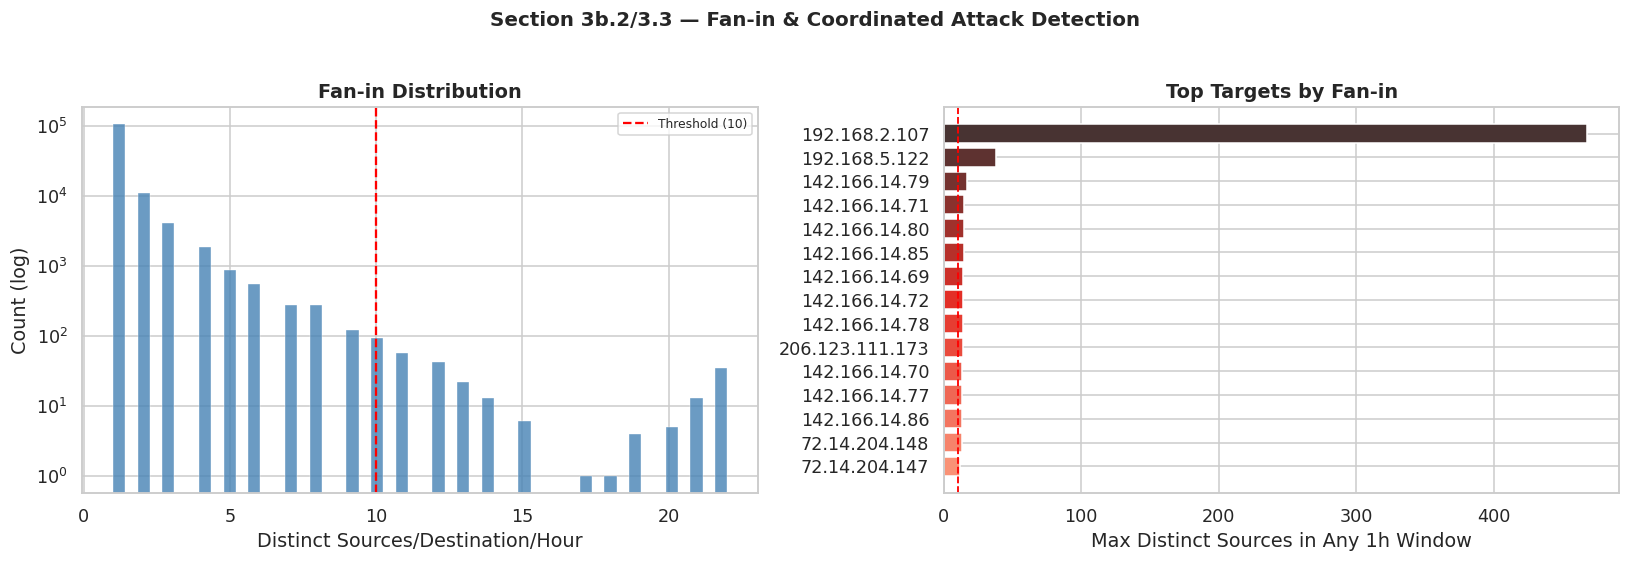

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fi_clip = fanin['unique_sources']
fi_clip = fi_clip[fi_clip <= fi_clip.quantile(0.999)]
axes[0].hist(fi_clip, bins=50, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.8, log=True)
axes[0].axvline(FANIN_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({FANIN_THRESHOLD})')
axes[0].set_xlabel('Distinct Sources/Destination/Hour'); axes[0].set_ylabel('Count (log)')
axes[0].set_title('Fan-in Distribution', fontweight='bold'); axes[0].legend(fontsize=8)

top_fi = fanin_anomalies.groupby('destination')['unique_sources'].max().nlargest(15).reset_index()
axes[1].barh(top_fi['destination'][::-1], top_fi['unique_sources'][::-1],
             color=sns.color_palette('Reds_d', len(top_fi)))
axes[1].axvline(FANIN_THRESHOLD, color='red', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Max Distinct Sources in Any 1h Window')
axes[1].set_title('Top Targets by Fan-in', fontweight='bold')

plt.suptitle('Section 3b.2/3.3 — Fan-in & Coordinated Attack Detection', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('3b2_fanin.png', bbox_inches='tight')
plt.show()

### 3c.1 — Long Duration Connections

Connections lasting more than mean + 3σ of the duration distribution are flagged. Unusually long connections can indicate persistent backdoors, C2 channels, slow data exfiltration, or keep-alive abuse.

In [40]:
dur = df['duration_sec'].dropna()
dur_mean, dur_std = dur.mean(), dur.std()
dur_threshold = dur_mean + 3 * dur_std
long_conns = df[df['duration_sec'] >= dur_threshold].sort_values('duration_sec', ascending=False)

print(f"Duration mean          : {dur_mean:.1f} seconds")
print(f"Duration std           : {dur_std:.1f} seconds")
print(f"Long conn threshold    : {dur_threshold:.1f}s ({dur_threshold/3600:.2f} hours)")
print(f"Long connections       : {len(long_conns):,}  ({len(long_conns)/len(df)*100:.2f}%)")
print(f"Attack among long conns: {long_conns['is_attack'].mean()*100:.1f}%")
print("\nTop 20 longest connections:")
print(long_conns[['source','destination','duration_sec','protocolName','appName','totalBytes','Label']].head(20).to_string(index=False))

Duration mean          : 49.0 seconds
Duration std           : 619.8 seconds
Long conn threshold    : 1908.3s (0.53 hours)
Long connections       : 7,628  (0.37%)
Attack among long conns: 0.1%

Top 20 longest connections:
       source     destination  duration_sec protocolName     appName  totalBytes  Label
192.168.1.101   192.168.1.255       49140.0       udp_ip Unknown_UDP      163332 Normal
192.168.1.101 255.255.255.255       49140.0       udp_ip Unknown_UDP      163332 Normal
192.168.2.109 255.255.255.255       48960.0       udp_ip Unknown_UDP      163020 Normal
192.168.2.109   192.168.2.255       48960.0       udp_ip Unknown_UDP      163020 Normal
192.168.2.112   192.168.2.109       48900.0       tcp_ip   SecureWeb      511364 Normal
192.168.2.112   192.168.2.255       48900.0       udp_ip Unknown_UDP      163176 Normal
192.168.2.112 255.255.255.255       48900.0       udp_ip Unknown_UDP      163176 Normal
192.168.3.117 255.255.255.255       48780.0       udp_ip Unknown_UDP      

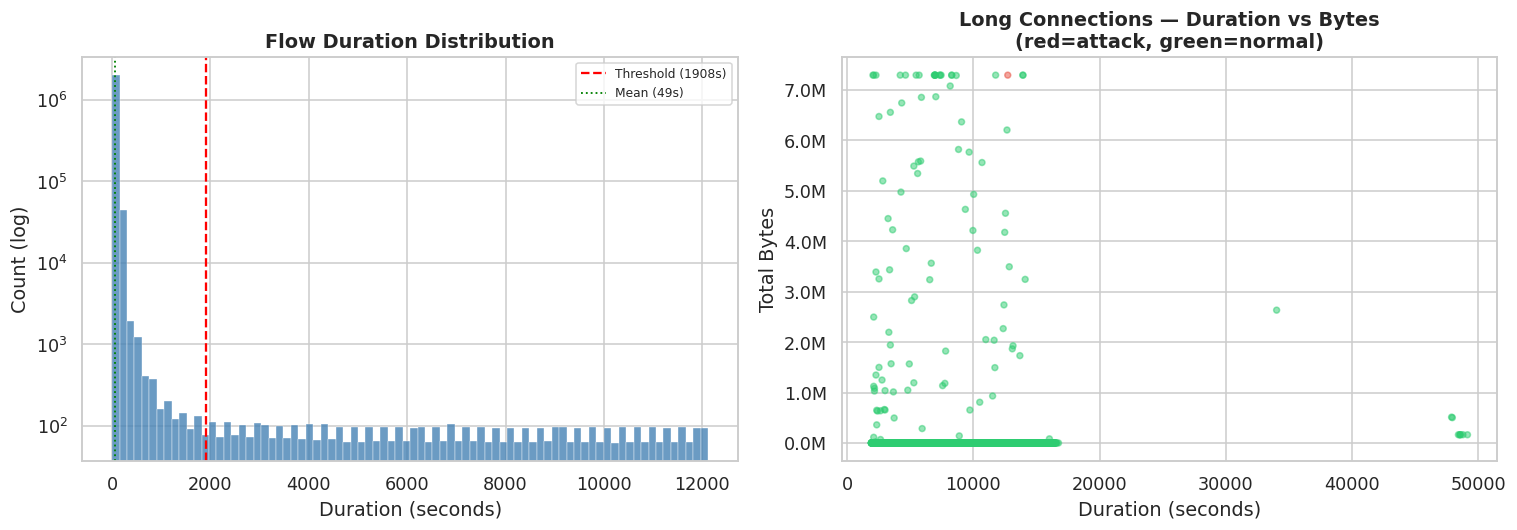

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dur_clip = dur[dur <= dur.quantile(0.999)]
axes[0].hist(dur_clip, bins=80, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.8, log=True)
axes[0].axvline(dur_threshold, color='red',   linestyle='--', linewidth=1.5, label=f'Threshold ({dur_threshold:.0f}s)')
axes[0].axvline(dur_mean,      color='green', linestyle=':',  linewidth=1.2, label=f'Mean ({dur_mean:.0f}s)')
axes[0].set_xlabel('Duration (seconds)'); axes[0].set_ylabel('Count (log)')
axes[0].set_title('Flow Duration Distribution', fontweight='bold'); axes[0].legend(fontsize=8)

sample = long_conns.sample(min(2000, len(long_conns)), random_state=42)
colors = ['#e74c3c' if a else '#2ecc71' for a in sample['is_attack']]
axes[1].scatter(sample['duration_sec'],
                sample['totalBytes'].clip(upper=sample['totalBytes'].quantile(0.99)),
                c=colors, alpha=0.5, s=15)
axes[1].set_xlabel('Duration (seconds)'); axes[1].set_ylabel('Total Bytes')
axes[1].set_title('Long Connections — Duration vs Bytes\n(red=attack, green=normal)', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('3c1_long_connections.png', bbox_inches='tight')
plt.show()

### 3c.2 — Multi-Protocol IPs in Short Time Windows

An IP using 2+ distinct protocols within a 10-minute window is flagged. Normal hosts typically use one protocol at a time; protocol diversity suggests scanning or protocol-switching evasion.

In [42]:
multi_proto = (
    df_ts.groupby([pd.Grouper(freq='10min'), 'source'])
         .agg(n_protocols  = ('protocolName', 'nunique'),
              protocols    = ('protocolName', lambda x: ', '.join(sorted(x.unique()))),
              flow_count   = ('totalBytes',   'count'),
              unique_ports = ('destinationPort', 'nunique'))
         .reset_index()
)
multi_proto.columns = ['window','source','n_protocols','protocols','flow_count','unique_ports']

multi_anomalies = multi_proto[multi_proto['n_protocols'] >= MULTIPROTO_THRESHOLD].sort_values('n_protocols', ascending=False)
print(f"Multi-protocol threshold : ≥ {MULTIPROTO_THRESHOLD} protocols / 10-min window")
print(f"Anomalous (IP, window)   : {len(multi_anomalies):,}")
print(f"Unique source IPs        : {multi_anomalies['source'].nunique()}")
print("\nTop 20 multi-protocol events:")
print(multi_anomalies[['source','window','n_protocols','protocols','flow_count','unique_ports']].head(20).to_string(index=False))

Multi-protocol threshold : ≥ 2 protocols / 10-min window
Anomalous (IP, window)   : 17,109
Unique source IPs        : 36

Top 20 multi-protocol events:
       source              window  n_protocols                     protocols  flow_count  unique_ports
192.168.2.107 2010-06-14 21:50:00            4 icmp_ip, igmp, tcp_ip, udp_ip        1040           713
192.168.5.122 2010-06-16 10:20:00            3       icmp_ip, tcp_ip, udp_ip         862             3
192.168.5.122 2010-06-14 11:40:00            3       icmp_ip, tcp_ip, udp_ip         213             3
192.168.5.122 2010-06-15 00:50:00            3       icmp_ip, tcp_ip, udp_ip         215             3
192.168.2.107 2010-06-12 03:20:00            3          igmp, tcp_ip, udp_ip           9             7
192.168.5.122 2010-06-15 11:20:00            3       icmp_ip, tcp_ip, udp_ip         953             3
192.168.5.122 2010-06-16 16:00:00            3       icmp_ip, tcp_ip, udp_ip         583             4
192.168.5.122 2010-06-17

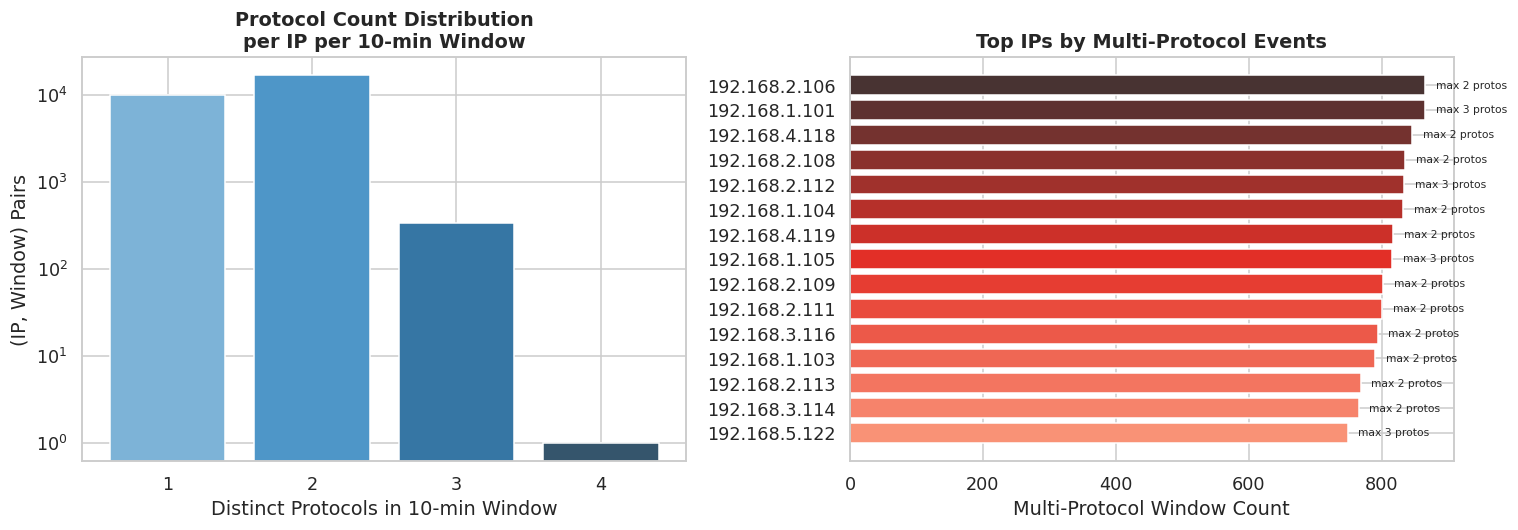

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_proto_counts = multi_proto['n_protocols'].value_counts().sort_index()
axes[0].bar(n_proto_counts.index.astype(str), n_proto_counts.values,
            color=sns.color_palette('Blues_d', len(n_proto_counts)), edgecolor='white')
axes[0].set_xlabel('Distinct Protocols in 10-min Window'); axes[0].set_ylabel('(IP, Window) Pairs')
axes[0].set_title('Protocol Count Distribution\nper IP per 10-min Window', fontweight='bold')
axes[0].set_yscale('log')

ip_mp = (multi_anomalies.groupby('source')
          .agg(events=('window','count'), max_protos=('n_protocols','max'))
          .sort_values('events', ascending=False).head(15).reset_index())
axes[1].barh(ip_mp['source'][::-1], ip_mp['events'][::-1],
             color=sns.color_palette('Reds_d', len(ip_mp)))
axes[1].set_xlabel('Multi-Protocol Window Count')
axes[1].set_title('Top IPs by Multi-Protocol Events', fontweight='bold')
for i, (_, row) in enumerate(ip_mp[::-1].iterrows()):
    axes[1].text(row['events']*1.02, i, f"max {row['max_protos']} protos", va='center', fontsize=7)

plt.tight_layout()
plt.savefig('3c2_multiprotocol.png', bbox_inches='tight')
plt.show()

---
## Phase 4 — Deep Security Threat Analysis

Building on the anomalies from Phase 3, we now perform targeted threat hunting: stealthy port scans, slow DDoS trends, IP hopping, payload pattern matching, encrypted traffic anomalies, C2 beaconing, and finally risk classification of all detected events.

### 4a.1 — Stealthy Port Scan Detection

A stealthy scanner probes many ports slowly over time, keeping individual flow volumes small to avoid rate-based detection. Signature: > 100 distinct destination ports contacted, mean bytes < 500, mean packets < 5 per flow.

In [44]:
src_port_stats = (
    df.groupby('source')
      .agg(n_distinct_ports = ('destinationPort', 'nunique'),
           n_distinct_dsts  = ('destination',     'nunique'),
           n_flows          = ('totalBytes',       'count'),
           mean_bytes       = ('totalBytes',       'mean'),
           mean_packets     = ('totalPackets',     'mean'),
           first_seen       = ('startDateTime',    'min'),
           last_seen        = ('startDateTime',    'max'),
           attack_pct       = ('is_attack',        lambda x: x.mean()*100),
           protocols        = ('protocolName',     lambda x: ', '.join(sorted(x.unique()))))
      .reset_index()
)
src_port_stats['time_span_hours'] = (
    (src_port_stats['last_seen'] - src_port_stats['first_seen']).dt.total_seconds() / 3600
)
src_port_stats['ports_per_hour'] = (
    src_port_stats['n_distinct_ports'] / src_port_stats['time_span_hours'].replace(0, np.nan)
)

# Stealthy: many ports, small flows, few packets
scanners = src_port_stats[
    (src_port_stats['n_distinct_ports'] > PORTSCAN_THRESHOLD) &
    (src_port_stats['mean_bytes']   < 500) &
    (src_port_stats['mean_packets'] < 5)
].sort_values('n_distinct_ports', ascending=False)

extreme_scanners = src_port_stats[
    src_port_stats['n_distinct_ports'] > 1000
].sort_values('n_distinct_ports', ascending=False)

scanner_ips = set(scanners['source'].tolist() + extreme_scanners['source'].tolist())
cols = ['source','n_distinct_ports','n_distinct_dsts','time_span_hours',
        'ports_per_hour','mean_bytes','mean_packets','attack_pct']
print(f"Stealthy scanners  : {len(scanners)}")
print(f"Extreme scanners   : {len(extreme_scanners)} (>1000 ports)")
print("\nStealthy port scanners:")
print(scanners[cols].round(2).to_string(index=False))
print("\nExtreme port scanners (>1000 ports):")
print(extreme_scanners[cols].round(2).head(10).to_string(index=False))

Stealthy scanners  : 0
Extreme scanners   : 4 (>1000 ports)

Stealthy port scanners:
Empty DataFrame
Columns: [source, n_distinct_ports, n_distinct_dsts, time_span_hours, ports_per_hour, mean_bytes, mean_packets, attack_pct]
Index: []

Extreme port scanners (>1000 ports):
       source  n_distinct_ports  n_distinct_dsts  time_span_hours  ports_per_hour  mean_bytes  mean_packets  attack_pct
192.168.2.107             16961            23744           143.93          117.84    23328.14         37.60        0.00
192.168.4.121              3668             2138           147.80           24.82    35558.48         49.94        0.02
192.168.1.105              1610             1979           143.98           11.18    34116.69         51.33       20.06
192.168.2.112              1150             1849           143.98            7.99    65229.35         79.19        5.90


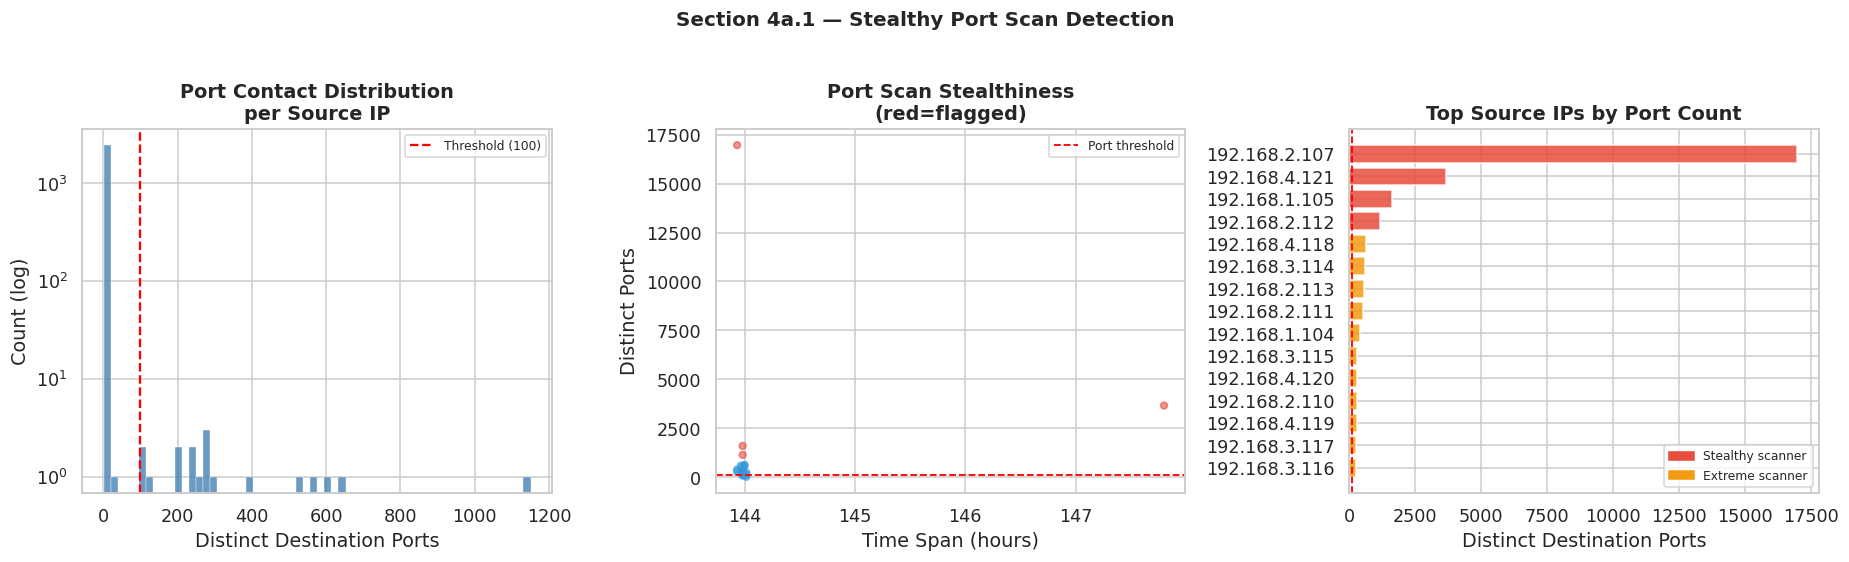

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

nports_clip = src_port_stats['n_distinct_ports']
nports_clip = nports_clip[nports_clip <= nports_clip.quantile(0.999)]
axes[0].hist(nports_clip, bins=60, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.8, log=True)
axes[0].axvline(PORTSCAN_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({PORTSCAN_THRESHOLD})')
axes[0].set_xlabel('Distinct Destination Ports'); axes[0].set_ylabel('Count (log)')
axes[0].set_title('Port Contact Distribution\nper Source IP', fontweight='bold'); axes[0].legend(fontsize=8)

all_p = src_port_stats[src_port_stats['n_distinct_ports'] > 10]
is_sc  = all_p['source'].isin(scanner_ips)
axes[1].scatter(all_p['time_span_hours'], all_p['n_distinct_ports'],
                c=['#e74c3c' if s else '#3498db' for s in is_sc], alpha=0.6, s=20)
axes[1].axhline(PORTSCAN_THRESHOLD, color='red', linestyle='--', linewidth=1.2, label=f'Port threshold')
axes[1].set_xlabel('Time Span (hours)'); axes[1].set_ylabel('Distinct Ports')
axes[1].set_title('Port Scan Stealthiness\n(red=flagged)', fontweight='bold'); axes[1].legend(fontsize=8)

top_scan = src_port_stats.nlargest(15, 'n_distinct_ports')
bc = ['#e74c3c' if ip in scanner_ips else '#f39c12' for ip in top_scan['source']]
axes[2].barh(top_scan['source'][::-1], top_scan['n_distinct_ports'][::-1], color=bc[::-1], alpha=0.85)
axes[2].axvline(PORTSCAN_THRESHOLD, color='red', linestyle='--', linewidth=1.2)
axes[2].set_xlabel('Distinct Destination Ports')
axes[2].set_title('Top Source IPs by Port Count', fontweight='bold')
axes[2].legend(handles=[mpatches.Patch(color='#e74c3c', label='Stealthy scanner'),
                         mpatches.Patch(color='#f39c12', label='Extreme scanner')], fontsize=8)
plt.suptitle('Section 4a.1 — Stealthy Port Scan Detection', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('4a1_port_scan.png', bbox_inches='tight')
plt.show()

### 4a.2 — Slow DDoS Detection

Slow DDoS attacks gradually ramp up traffic to a target without triggering spike-based alerts. We fit a linear trend to each destination's 30-minute rolling flow counts and flag those with a statistically significant positive slope (p < 0.05), indicating sustained growth.

In [46]:
dst_rolling = (
    df_ts.groupby([pd.Grouper(freq=SLOW_DDOS_WINDOW), 'destination'])
         .agg(flow_count  = ('totalBytes', 'count'),
              unique_srcs = ('source',     'nunique'),
              total_bytes = ('totalBytes', 'sum'))
         .reset_index()
)
dst_rolling.columns = ['window','destination','flow_count','unique_srcs','total_bytes']
dst_rolling = dst_rolling.sort_values(['destination','window'])

slow_ddos_candidates = []
for dst, grp in dst_rolling.groupby('destination'):
    if len(grp) < 6: continue
    grp = grp.sort_values('window')
    x = np.arange(len(grp)); y = grp['flow_count'].values
    if y.max() == 0: continue
    slope, intercept, r, p, _ = stats.linregress(x, y)
    if slope > 0 and p < 0.05 and y.min() > 0:
        slow_ddos_candidates.append({
            'destination': dst, 'slope': round(slope, 3),
            'r_squared': round(r**2, 3), 'p_value': round(p, 4),
            'mean_flow_cnt': round(y.mean(), 1), 'max_flow_cnt': int(y.max()),
            'n_windows': len(grp), 'max_srcs': int(grp['unique_srcs'].max()),
            'total_bytes': int(grp['total_bytes'].sum())
        })

df_slow_ddos = pd.DataFrame(slow_ddos_candidates).sort_values('slope', ascending=False)
print(f"Destinations analysed : {dst_rolling['destination'].nunique():,}")
print(f"Slow DDoS candidates  : {len(df_slow_ddos)}")
print("\nTop 20 by slope (steepest sustained growth):")
print(df_slow_ddos.head(20).to_string(index=False))

Destinations analysed : 34,555
Slow DDoS candidates  : 266

Top 20 by slope (steepest sustained growth):
   destination  slope  r_squared  p_value  mean_flow_cnt  max_flow_cnt  n_windows  max_srcs  total_bytes
195.189.244.14 17.879      0.615   0.0000          260.6           576         22         1    216145808
   72.32.6.120 13.082      0.276   0.0253           63.7           528         18         1     49909257
203.99.146.150  6.179      0.561   0.0326           21.6            69          8         1      5554071
    192.5.6.31  6.107      0.830   0.0043           15.1            33          7         1        13362
204.236.225.39  6.054      0.202   0.0003          132.2          1093         61         3     34587018
 203.99.146.13  5.829      0.731   0.0300           11.7            29          6         1      1528487
  74.86.23.180  5.314      0.859   0.0078           11.7            28          6         1     17838213
  77.72.113.23  5.056      0.541   0.0003           49.

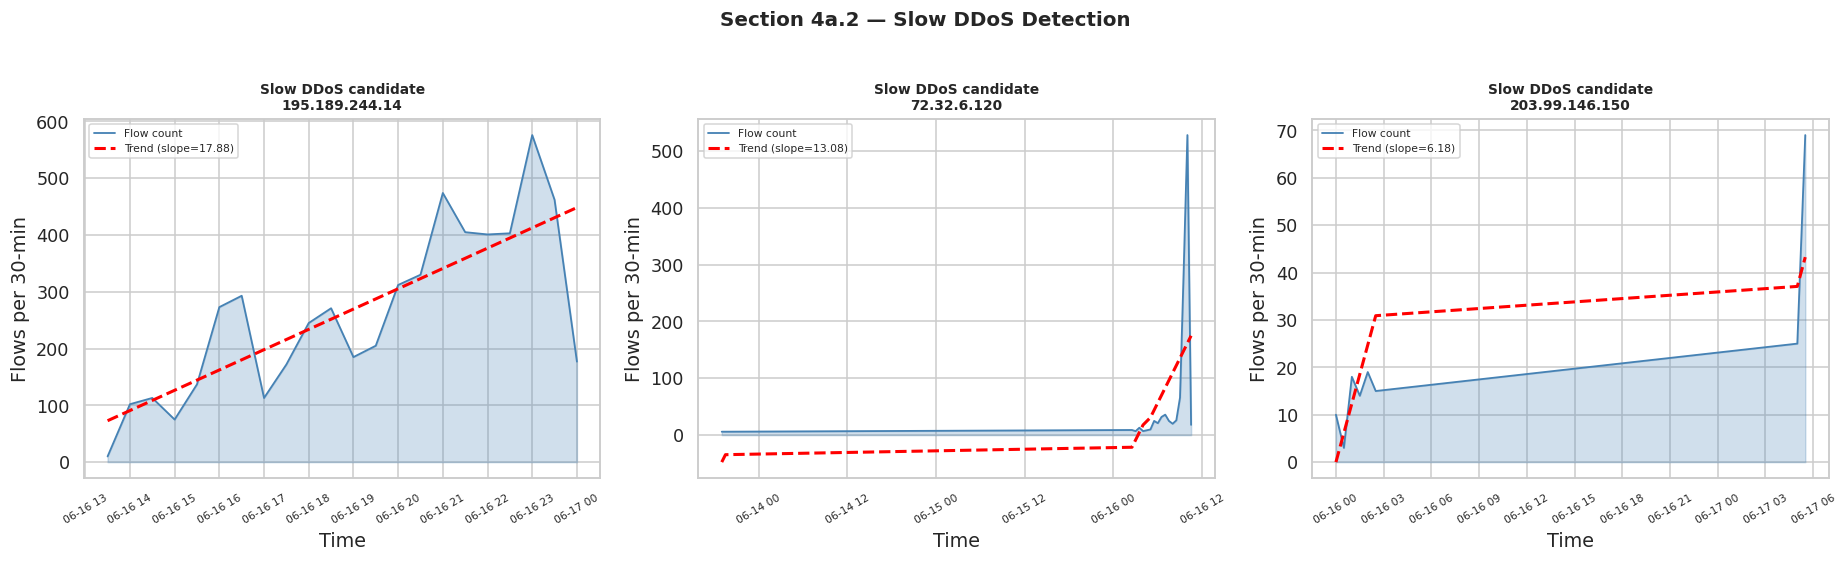

In [47]:
top_targets = df_slow_ddos.head(3)['destination'].tolist()
fig, axes   = plt.subplots(1, len(top_targets), figsize=(17, 5), sharey=False)
if len(top_targets) == 1: axes = [axes]

for ax, dst in zip(axes, top_targets):
    grp  = dst_rolling[dst_rolling['destination'] == dst].sort_values('window')
    x    = np.arange(len(grp)); y = grp['flow_count'].values
    slope, intercept, *_ = stats.linregress(x, y)
    ax.fill_between(grp['window'], y, alpha=0.25, color='steelblue')
    ax.plot(grp['window'], y, linewidth=1.2, color='steelblue', label='Flow count')
    ax.plot(grp['window'], intercept + slope*x, linewidth=2, color='red', linestyle='--',
            label=f'Trend (slope={slope:.2f})')
    ax.set_title(f'Slow DDoS candidate\n{dst}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Time'); ax.set_ylabel('Flows per 30-min')
    ax.legend(fontsize=7); ax.tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Section 4a.2 — Slow DDoS Detection', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('4a2_slow_ddos.png', bbox_inches='tight')
plt.show()

### 4a.3 — IP Hopping Detection

IP hopping is when an attacker rotates through multiple source IPs to evade per-IP rate limits or blocklists. Signature: ≥ 3 distinct source IPs contacting the same destination on the same port within a 10-minute window.

In [48]:
hopping = (
    df_ts.groupby([pd.Grouper(freq='10min'), 'destination', 'destinationPort'])
         .agg(unique_srcs  = ('source',      'nunique'),
              src_list     = ('source',      lambda x: list(x.unique())),
              flow_count   = ('totalBytes',  'count'),
              protocols    = ('protocolName', lambda x: ', '.join(sorted(x.unique()))),
              attack_count = ('is_attack',   'sum'))
         .reset_index()
)
hopping.columns = ['window','destination','destinationPort',
                   'unique_srcs','src_list','flow_count','protocols','attack_count']

hop_events = hopping[hopping['unique_srcs'] >= IP_HOP_THRESHOLD].sort_values('unique_srcs', ascending=False)
print(f"IP hop threshold   : ≥ {IP_HOP_THRESHOLD} source IPs/dest/port/10-min")
print(f"Hop events         : {len(hop_events):,}")
print(f"Unique dest IPs    : {hop_events['destination'].nunique()}")
print(f"Unique dest ports  : {hop_events['destinationPort'].nunique()}")
print("\nTop 20 IP hopping events:")
print(hop_events[['window','destination','destinationPort','unique_srcs','flow_count','protocols','attack_count']].head(20).to_string(index=False))

print("\nSubnet analysis for top 5 hop events:")
for _, row in hop_events.head(5).iterrows():
    subnets = set('.'.join(ip.split('.')[:3]) for ip in row['src_list'])
    print(f"  {row['destination']}:{int(row['destinationPort'])} | {row['unique_srcs']} sources | subnets: {subnets}")

IP hop threshold   : ≥ 3 source IPs/dest/port/10-min
Hop events         : 14,944
Unique dest IPs    : 478
Unique dest ports  : 17

Top 20 IP hopping events:
             window   destination  destinationPort  unique_srcs  flow_count protocols  attack_count
2010-06-15 07:50:00 192.168.2.107                0          186         253   icmp_ip             0
2010-06-15 03:20:00 192.168.2.107                0          181         243   icmp_ip             0
2010-06-15 01:50:00 192.168.2.107                0          172         188   icmp_ip             0
2010-06-15 06:20:00 192.168.2.107                0          171         248   icmp_ip             0
2010-06-15 02:00:00 192.168.2.107                0          166         216   icmp_ip             0
2010-06-15 04:50:00 192.168.2.107                0          162         216   icmp_ip             0
2010-06-15 02:50:00 192.168.2.107                0          155         210   icmp_ip             0
2010-06-15 05:50:00 192.168.2.107          

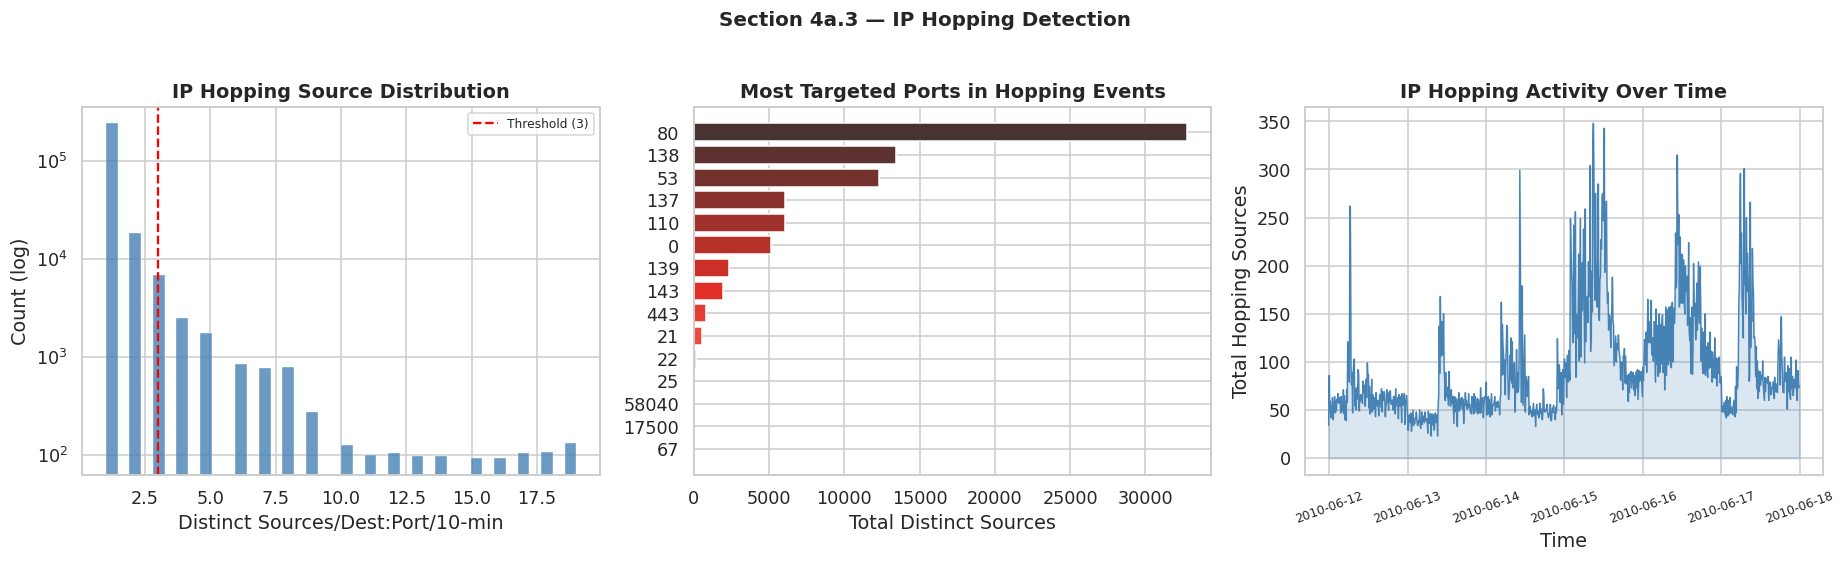

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

usrc_clip = hopping['unique_srcs']
usrc_clip = usrc_clip[usrc_clip <= usrc_clip.quantile(0.999)]
axes[0].hist(usrc_clip, bins=40, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.8, log=True)
axes[0].axvline(IP_HOP_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({IP_HOP_THRESHOLD})')
axes[0].set_xlabel('Distinct Sources/Dest:Port/10-min'); axes[0].set_ylabel('Count (log)')
axes[0].set_title('IP Hopping Source Distribution', fontweight='bold'); axes[0].legend(fontsize=8)

port_hop = hop_events.groupby('destinationPort')['unique_srcs'].sum().nlargest(15).reset_index()
axes[1].barh(port_hop['destinationPort'].astype(str)[::-1], port_hop['unique_srcs'][::-1],
             color=sns.color_palette('Reds_d', len(port_hop)))
axes[1].set_xlabel('Total Distinct Sources'); axes[1].set_title('Most Targeted Ports in Hopping Events', fontweight='bold')

hop_ts = hop_events.groupby('window')['unique_srcs'].sum()
axes[2].plot(hop_ts.index, hop_ts.values, linewidth=0.9, color='steelblue')
axes[2].fill_between(hop_ts.index, hop_ts.values, alpha=0.2, color='steelblue')
axes[2].set_xlabel('Time'); axes[2].set_ylabel('Total Hopping Sources')
axes[2].set_title('IP Hopping Activity Over Time', fontweight='bold')
axes[2].tick_params(axis='x', rotation=20, labelsize=8)

plt.suptitle('Section 4a.3 — IP Hopping Detection', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('4a3_ip_hopping.png', bbox_inches='tight')
plt.show()

### 4b — Malicious Payload Identification & C2 Detection

**4b.1** — Regex-based payload pattern matching on `sourcePayloadAsUTF` for IRC commands, shell invocations, SQL injection, directory traversal, base64 blobs, HTTP exploits, and bot commands.

**4b.2** — Encrypted traffic (ports 443/22) is profiled; very short HTTPS flows suggest TLS probes/scans and large SSH flows suggest exfiltration.

**4b.3** — C2 beaconing is detected by computing inter-arrival times per (source, destination) pair and flagging those with a coefficient of variation (CV) below 0.25, indicating highly periodic connections.

In [50]:
# ── 4b.1: Payload pattern matching ──
payload_df = df[df['sourcePayloadAsUTF'].notna() & (df['sourcePayloadAsUTF'].str.strip() != '')].copy()
print(f"Flows with payload data   : {len(payload_df):,}")
print(f"Attack flows with payload : {payload_df['is_attack'].sum():,} ({payload_df['is_attack'].mean()*100:.1f}%)")

suspicious_patterns = {
    'IRC commands'       : r'(PRIVMSG|JOIN|NICK|USER|PASS|PING|PONG)\s',
    'Shell commands'     : r'(/bin/sh|/bin/bash|cmd\.exe|powershell)',
    'SQL injection'      : r'(SELECT|UNION|DROP|INSERT|UPDATE)\s+\w',
    'Directory traversal': r'(\.\./|\.\.\\ ){2,}',
    'Base64 encoded'     : r'[A-Za-z0-9+/]{40,}={0,2}',
    'HTTP exploits'      : r'(eval\(|exec\(|system\(|passthru\()',
    'Bot commands'       : r'(\.scan|\.udpflood|\.tcpflood|\.killall)',
}

print("\nSuspicious payload pattern matches:")
pattern_results = {}
for name, pattern in suspicious_patterns.items():
    matches = payload_df[payload_df['sourcePayloadAsUTF'].str.contains(pattern, case=False, regex=True, na=False)]
    pattern_results[name] = matches
    if len(matches) > 0:
        print(f"  {name:<22}: {len(matches):>6,} flows  ({matches['is_attack'].mean()*100:.1f}% attack)")

# ── 4b.2: Encrypted traffic anomaly ──
print("\n[4b.2] Encrypted traffic anomalies:")
encrypted = df[df['destinationPort'].isin([443, 22])].copy()
non_enc   = df[~df['destinationPort'].isin([443, 22])].copy()

tls_short = encrypted[(encrypted['destinationPort']==443) &
                       (encrypted['duration_sec'] < 1) & (encrypted['totalBytes'] < 200)]
ssh_large = encrypted[(encrypted['destinationPort']==22) &
                       (encrypted['totalBytes'] > encrypted[encrypted['destinationPort']==22]['totalBytes'].quantile(0.99))]
print(f"  Anomalous TLS (port 443) — very short+small: {len(tls_short):,}  (attack: {tls_short['is_attack'].mean()*100:.1f}%)")
print(f"  Anomalous SSH (port 22) — unusually large  : {len(ssh_large):,}  (attack: {ssh_large['is_attack'].mean()*100:.1f}%)")

Flows with payload data   : 888,802
Attack flows with payload : 38,023 (4.3%)

Suspicious payload pattern matches:
  IRC commands          : 12,818 flows  (1.9% attack)
  Shell commands        :      2 flows  (100.0% attack)
  SQL injection         :     54 flows  (7.4% attack)
  Directory traversal   :      9 flows  (44.4% attack)
  Base64 encoded        : 40,179 flows  (0.2% attack)
  Bot commands          :     36 flows  (0.0% attack)

[4b.2] Encrypted traffic anomalies:
  Anomalous TLS (port 443) — very short+small: 3,940  (attack: 10.4%)
  Anomalous SSH (port 22) — unusually large  : 100  (attack: 0.0%)


In [51]:
# ── 4b.3: C2 beaconing detection ──
print("[4b.3] C2 Beaconing Detection")
print(f"  Method: inter-arrival CV < {BEACON_REGULARITY} AND interval > 10s")

pair_times = (
    df.groupby(['source','destination'])['startDateTime']
      .apply(lambda x: sorted(x)).reset_index()
)
pair_times.columns = ['source','destination','times']

beacon_candidates = []
for _, row in pair_times.iterrows():
    times = row['times']
    if len(times) < BEACON_MIN_PERIODS: continue
    intervals = np.array([(times[i+1]-times[i]).total_seconds() for i in range(len(times)-1)])
    intervals = intervals[intervals > 0]
    if len(intervals) < BEACON_MIN_PERIODS - 1: continue
    mean_iv = np.mean(intervals); std_iv = np.std(intervals)
    cv = std_iv / mean_iv if mean_iv > 0 else np.inf
    if cv < BEACON_REGULARITY and mean_iv > 10:
        src_dst = df[(df['source']==row['source']) & (df['destination']==row['destination'])]
        beacon_candidates.append({
            'source': row['source'], 'destination': row['destination'],
            'n_connections': len(times),
            'mean_interval_s': round(mean_iv, 1), 'std_interval_s': round(std_iv, 1),
            'cv': round(cv, 4), 'attack_pct': round(src_dst['is_attack'].mean()*100, 1),
            'dst_port': src_dst['destinationPort'].mode().iloc[0] if len(src_dst) > 0 else None,
            'app': src_dst['appName'].mode().iloc[0] if len(src_dst) > 0 else None,
        })

df_beacons = pd.DataFrame(beacon_candidates).sort_values('cv')
print(f"\n  Beacon candidates (CV < {BEACON_REGULARITY}, interval > 10s): {len(df_beacons)}")
if len(df_beacons) > 0:
    print("\n  Top 20 most regular beacons (lowest CV = most periodic):")
    print(df_beacons.head(20).to_string(index=False))

[4b.3] C2 Beaconing Detection
  Method: inter-arrival CV < 0.25 AND interval > 10s

  Beacon candidates (CV < 0.25, interval > 10s): 285

  Top 20 most regular beacons (lowest CV = most periodic):
       source     destination  n_connections  mean_interval_s  std_interval_s  cv  attack_pct  dst_port               app
192.168.1.101  119.160.252.12             22             60.0             0.0 0.0         0.0        80           HTTPWeb
192.168.1.101      192.0.32.7             12             60.0             0.0 0.0         0.0        80 HTTPImageTransfer
192.168.1.101   66.147.242.89              8             60.0             0.0 0.0         0.0        80 HTTPImageTransfer
192.168.1.101  204.232.147.30             43             60.0             0.0 0.0         0.0        80           HTTPWeb
192.168.1.103   209.84.24.126             11             60.0             0.0 0.0         0.0        80 HTTPImageTransfer
192.168.1.101     72.3.139.31              8             60.0          

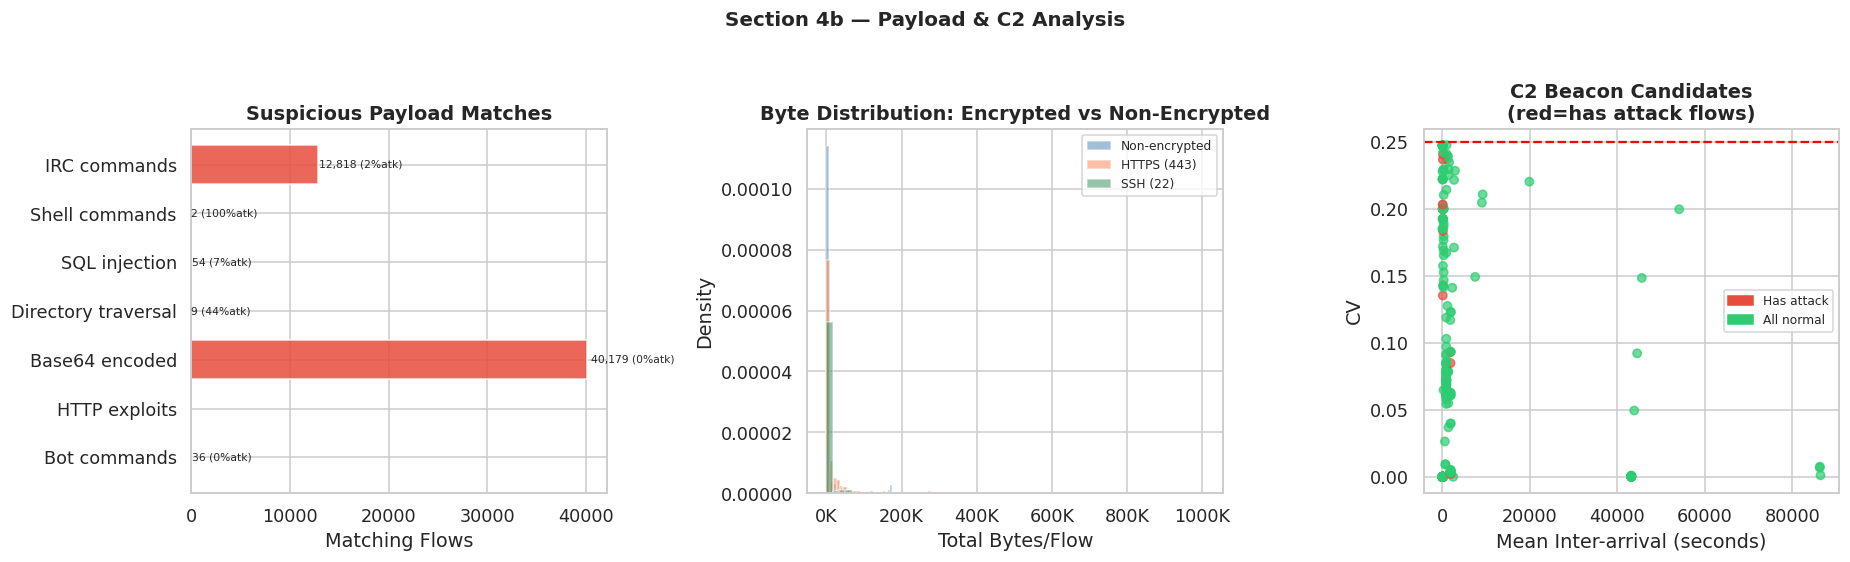

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

pat_names  = list(suspicious_patterns.keys())
pat_counts = [len(pattern_results[n]) for n in pat_names]
pat_atk    = [pattern_results[n]['is_attack'].mean()*100 if len(pattern_results[n])>0 else 0 for n in pat_names]
bc = ['#e74c3c' if c > 0 else '#95a5a6' for c in pat_counts]
axes[0].barh(pat_names[::-1], pat_counts[::-1], color=bc[::-1], alpha=0.85)
axes[0].set_xlabel('Matching Flows')
axes[0].set_title('Suspicious Payload Matches', fontweight='bold')
for i, (c, a) in enumerate(zip(pat_counts[::-1], pat_atk[::-1])):
    if c > 0: axes[0].text(c*1.01, i, f'{c:,} ({a:.0f}%atk)', va='center', fontsize=7)

enc443  = encrypted[encrypted['destinationPort']==443]['totalBytes']
enc22   = encrypted[encrypted['destinationPort']==22]['totalBytes']
ne_clip = non_enc['totalBytes']; ne_clip = ne_clip[ne_clip <= ne_clip.quantile(0.99)]
enc443c = enc443[enc443 <= enc443.quantile(0.99)]
enc22c  = enc22[enc22   <= enc22.quantile(0.99)]
axes[1].hist(ne_clip,  bins=60, alpha=0.5, color='steelblue', density=True, label='Non-encrypted')
axes[1].hist(enc443c,  bins=60, alpha=0.5, color='coral',     density=True, label='HTTPS (443)')
axes[1].hist(enc22c,   bins=60, alpha=0.5, color='seagreen',  density=True, label='SSH (22)')
axes[1].set_xlabel('Total Bytes/Flow'); axes[1].set_ylabel('Density')
axes[1].set_title('Byte Distribution: Encrypted vs Non-Encrypted', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

if len(df_beacons) > 0:
    colors_b = ['#e74c3c' if a > 0 else '#2ecc71' for a in df_beacons['attack_pct']]
    axes[2].scatter(df_beacons['mean_interval_s'], df_beacons['cv'], c=colors_b, alpha=0.7, s=30)
    axes[2].axhline(BEACON_REGULARITY, color='red', linestyle='--', linewidth=1.5, label=f'CV threshold ({BEACON_REGULARITY})')
    axes[2].set_xlabel('Mean Inter-arrival (seconds)'); axes[2].set_ylabel('CV')
    axes[2].set_title('C2 Beacon Candidates\n(red=has attack flows)', fontweight='bold')
    axes[2].legend(handles=[mpatches.Patch(color='#e74c3c', label='Has attack'),
                             mpatches.Patch(color='#2ecc71', label='All normal')], fontsize=8)
else:
    axes[2].text(0.5, 0.5, 'No beacon candidates\ndetected', ha='center', va='center',
                 transform=axes[2].transAxes, fontsize=12, color='gray')
    axes[2].set_title('C2 Beacon Candidates', fontweight='bold')

plt.suptitle('Section 4b — Payload & C2 Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('4b_payload_c2.png', bbox_inches='tight')
plt.show()

### 4c — Threat Attribution and Risk Classification

We aggregate all detected events from Phases 3 and 4 into a single event table and classify each into **High**, **Medium**, or **Low** risk:

| Risk Level | Criteria |
|------------|----------|
| **High**   | Attack% > 50%, extreme port scan (>1000 ports), confirmed C2 with attack traffic, SSH exfiltration |
| **Medium** | Attack% 10–50%, moderate scan (100–1000 ports), slow DDoS with R²>0.4, anomalous TLS |
| **Low**    | Attack% < 10%, weak statistical trend, single-occurrence anomaly |

In [53]:
events = []

# Port scanners
for _, row in scanners.iterrows():
    atk = df[df['source']==row['source']]['is_attack'].mean()*100
    events.append({'event_id': f"PS-{row['source']}", 'type': 'Port Scan',
        'source_ip': row['source'], 'target_ip': 'Multiple',
        'metric': f"{int(row['n_distinct_ports'])} ports, {row['time_span_hours']:.1f}h span",
        'attack_pct': round(atk, 1),
        'risk': 'High' if row['n_distinct_ports'] > 1000 else 'Medium'})

for _, row in extreme_scanners[~extreme_scanners['source'].isin(scanners['source'])].iterrows():
    atk = df[df['source']==row['source']]['is_attack'].mean()*100
    events.append({'event_id': f"PS-EX-{row['source']}", 'type': 'Extreme Port Scan',
        'source_ip': row['source'], 'target_ip': 'Multiple',
        'metric': f"{int(row['n_distinct_ports'])} distinct ports",
        'attack_pct': round(atk, 1), 'risk': 'High'})

# Slow DDoS
for _, row in df_slow_ddos.head(10).iterrows():
    atk = df[df['destination']==row['destination']]['is_attack'].mean()*100
    events.append({'event_id': f"SDDOS-{row['destination']}", 'type': 'Slow DDoS',
        'source_ip': 'Multiple', 'target_ip': row['destination'],
        'metric': f"slope={row['slope']}, R²={row['r_squared']}",
        'attack_pct': round(atk, 1),
        'risk': 'High' if row['r_squared']>0.7 and atk>10 else 'Medium' if row['r_squared']>0.4 else 'Low'})

# IP hopping
top_hop_dsts = hop_events.groupby('destination')['unique_srcs'].max().nlargest(10).reset_index()
for _, row in top_hop_dsts.iterrows():
    atk = df[df['destination']==row['destination']]['is_attack'].mean()*100
    events.append({'event_id': f"HOP-{row['destination']}", 'type': 'IP Hopping',
        'source_ip': 'Multiple', 'target_ip': row['destination'],
        'metric': f"max {row['unique_srcs']} sources/10-min", 'attack_pct': round(atk, 1),
        'risk': 'High' if row['unique_srcs']>20 else 'Medium' if row['unique_srcs']>5 else 'Low'})

# Encrypted traffic anomalies
if len(tls_short) > 0:
    events.append({'event_id': 'ENC-TLS-SHORT', 'type': 'Anomalous TLS',
        'source_ip': 'Multiple', 'target_ip': 'Port 443',
        'metric': f"{len(tls_short):,} very short TLS flows",
        'attack_pct': round(tls_short['is_attack'].mean()*100, 1), 'risk': 'Medium'})
if len(ssh_large) > 0:
    events.append({'event_id': 'ENC-SSH-LARGE', 'type': 'SSH Exfiltration',
        'source_ip': 'Multiple', 'target_ip': 'Port 22',
        'metric': f"{len(ssh_large):,} unusually large SSH flows",
        'attack_pct': round(ssh_large['is_attack'].mean()*100, 1),
        'risk': 'High' if ssh_large['is_attack'].mean()>0.1 else 'Medium'})

# C2 beaconing
if len(df_beacons) > 0:
    for _, row in df_beacons.head(10).iterrows():
        events.append({'event_id': f"C2-{row['source']}-{row['destination']}", 'type': 'C2 Beaconing',
            'source_ip': row['source'], 'target_ip': row['destination'],
            'metric': f"CV={row['cv']}, interval={row['mean_interval_s']}s",
            'attack_pct': row['attack_pct'],
            'risk': 'High' if row['attack_pct']>50 else 'Medium' if row['attack_pct']>10 else 'Low'})

# Payload patterns
for name, matches in pattern_results.items():
    if len(matches) > 0:
        atk = matches['is_attack'].mean()*100
        events.append({'event_id': f"PAY-{name.replace(' ','-')}", 'type': f'Payload: {name}',
            'source_ip': 'Multiple', 'target_ip': 'Multiple',
            'metric': f"{len(matches):,} matching flows", 'attack_pct': round(atk, 1),
            'risk': 'High' if atk>50 else 'Medium' if atk>10 else 'Low'})

df_events = pd.DataFrame(events)
risk_summary = df_events['risk'].value_counts()

print(f"Total events classified : {len(df_events)}")
print(f"  HIGH   : {risk_summary.get('High',   0)}")
print(f"  MEDIUM : {risk_summary.get('Medium', 0)}")
print(f"  LOW    : {risk_summary.get('Low',    0)}")
print()
print(df_events[['event_id','type','source_ip','target_ip','metric','attack_pct','risk']].to_string(index=False))

Total events classified : 42
  HIGH   : 7
  MEDIUM : 18
  LOW    : 17

                        event_id                         type     source_ip       target_ip                        metric  attack_pct   risk
             PS-EX-192.168.2.107            Extreme Port Scan 192.168.2.107        Multiple          16961 distinct ports         0.0   High
             PS-EX-192.168.4.121            Extreme Port Scan 192.168.4.121        Multiple           3668 distinct ports         0.0   High
             PS-EX-192.168.1.105            Extreme Port Scan 192.168.1.105        Multiple           1610 distinct ports        20.1   High
             PS-EX-192.168.2.112            Extreme Port Scan 192.168.2.112        Multiple           1150 distinct ports         5.9   High
            SDDOS-195.189.244.14                    Slow DDoS      Multiple  195.189.244.14        slope=17.879, R²=0.615         0.0 Medium
               SDDOS-72.32.6.120                    Slow DDoS      Multiple     72.

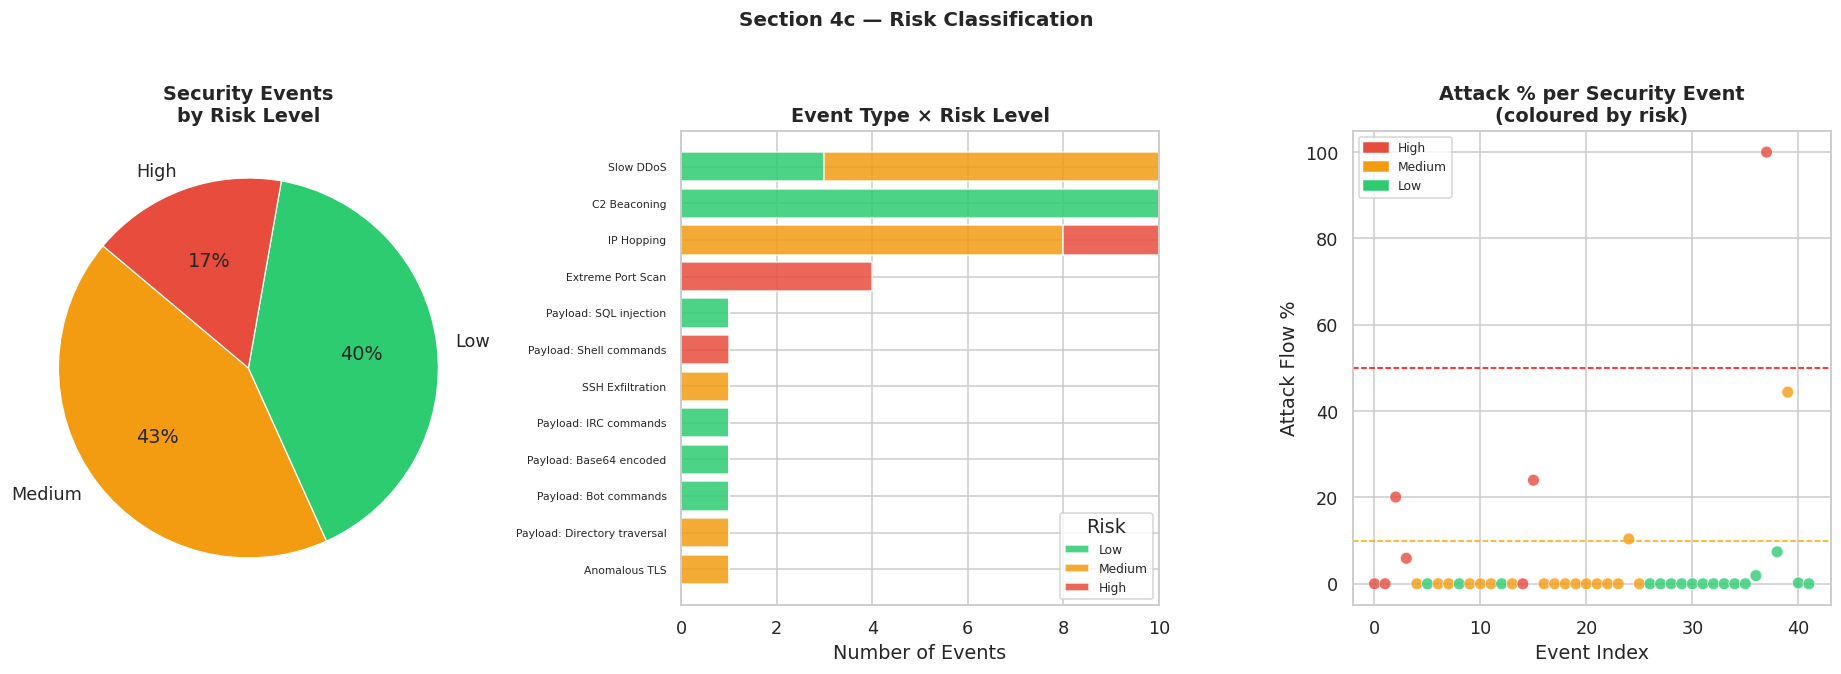

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
risk_colors = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#2ecc71'}

# Pie: risk distribution
rc = df_events['risk'].value_counts()
axes[0].pie(rc.values, labels=rc.index, autopct='%1.0f%%', startangle=140,
            colors=[risk_colors[r] for r in rc.index],
            wedgeprops=dict(linewidth=0.8, edgecolor='white'))
axes[0].set_title('Security Events\nby Risk Level', fontweight='bold')

# Stacked bar: event type × risk
type_risk   = df_events.groupby(['type','risk']).size().reset_index(name='count')
type_totals = type_risk.groupby('type')['count'].sum().sort_values()
ordered     = type_totals.index.tolist()
bottom      = np.zeros(len(ordered))
for rl in ['Low','Medium','High']:
    vals = [type_risk[(type_risk['type']==t)&(type_risk['risk']==rl)]['count'].sum() for t in ordered]
    axes[1].barh(ordered, vals, left=bottom, color=risk_colors[rl], alpha=0.85, label=rl)
    bottom += np.array(vals)
axes[1].set_xlabel('Number of Events'); axes[1].set_title('Event Type × Risk Level', fontweight='bold')
axes[1].legend(title='Risk', fontsize=8); axes[1].tick_params(axis='y', labelsize=7)

# Scatter: attack% per event
axes[2].scatter(range(len(df_events)), df_events['attack_pct'],
                c=[risk_colors[r] for r in df_events['risk']], s=60, alpha=0.8,
                edgecolors='white', linewidth=0.5)
axes[2].axhline(50, color='red',    linestyle='--', linewidth=1, label='50% attack')
axes[2].axhline(10, color='orange', linestyle='--', linewidth=1, label='10% attack')
axes[2].set_xlabel('Event Index'); axes[2].set_ylabel('Attack Flow %')
axes[2].set_title('Attack % per Security Event\n(coloured by risk)', fontweight='bold')
axes[2].legend(handles=[mpatches.Patch(color=c, label=r) for r, c in risk_colors.items()], fontsize=8)

plt.suptitle('Section 4c — Risk Classification', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('4c_risk_classification.png', bbox_inches='tight')
plt.show()

### Risk Report

In [55]:
payload_flagged = "\n".join(
    f"    {n:<22}: {len(v):>6,} flows"
    for n, v in pattern_results.items() if len(v) > 0
)

rows = []
rows.append("DATASET OVERVIEW")
rows.append(f"  Total flows     : {len(df):,}")
rows.append(f"  Time range      : {df['startDateTime'].min().date()} to {df['startDateTime'].max().date()}")
rows.append(f"  Attack flows    : {df['is_attack'].sum():,} ({df['is_attack'].mean()*100:.2f}%)")
rows.append(f"  Unique src IPs  : {df['source'].nunique():,}")
rows.append(f"  Unique dst IPs  : {df['destination'].nunique():,}")
rows.append("")
rows.append("SECTION 4a — COMPLEX ATTACK PATTERNS")
rows.append(f"  Stealthy scanners  : {len(scanners)} IPs (>{PORTSCAN_THRESHOLD} ports, small flows)")
rows.append(f"  Extreme scanners   : {len(extreme_scanners)} IPs (>1000 distinct ports)")
rows.append(f"  Slow DDoS targets  : {len(df_slow_ddos)} destination IPs")
rows.append(f"  IP hopping events  : {len(hop_events):,}")
rows.append("")
rows.append("SECTION 4b — MALICIOUS PAYLOAD & C2")
rows.append("  Payload patterns flagged:")
rows.append(payload_flagged)
rows.append(f"  Anomalous TLS flows : {len(tls_short):,}")
rows.append(f"  Anomalous SSH flows : {len(ssh_large):,}")
rows.append(f"  C2 beacon candidates: {len(df_beacons)}")
rows.append("")
rows.append("SECTION 4c — RISK ATTRIBUTION")
rows.append(f"  HIGH   risk events : {risk_summary.get('High',   0)}")
rows.append(f"  MEDIUM risk events : {risk_summary.get('Medium', 0)}")
rows.append(f"  LOW    risk events : {risk_summary.get('Low',    0)}")
rows.append(f"  Total events       : {len(df_events)}")
rows.append("")
rows.append("RECOMMENDATIONS")
rows.append("  1. Block all IPs flagged as extreme port scanners immediately.")
rows.append(f"  2. Rate-limit destinations with fan-in > {FANIN_THRESHOLD} distinct sources/hour.")
rows.append("  3. Inspect all flows matching IRC / bot command payload patterns.")
rows.append("  4. Set up dedicated packet capture for C2 beacon candidates.")
rows.append("  5. Review long-duration SSH flows for data exfiltration indicators.")
rows.append("  6. Deploy per-IP flow rate limits to counter IP hopping.")

print("=" * 65)
print("  PHASE 4 — DEEP SECURITY THREAT ANALYSIS — FINAL REPORT")
print("=" * 65)
print("\n".join(rows))
print("=" * 65)

  PHASE 4 — DEEP SECURITY THREAT ANALYSIS — FINAL REPORT
DATASET OVERVIEW
  Total flows     : 2,071,657
  Time range      : 2010-06-11 to 2010-06-17
  Attack flows    : 68,910 (3.33%)
  Unique src IPs  : 2,478
  Unique dst IPs  : 34,555

SECTION 4a — COMPLEX ATTACK PATTERNS
  Stealthy scanners  : 0 IPs (>100 ports, small flows)
  Extreme scanners   : 4 IPs (>1000 distinct ports)
  Slow DDoS targets  : 266 destination IPs
  IP hopping events  : 14,944

SECTION 4b — MALICIOUS PAYLOAD & C2
  Payload patterns flagged:
    IRC commands          : 12,818 flows
    Shell commands        :      2 flows
    SQL injection         :     54 flows
    Directory traversal   :      9 flows
    Base64 encoded        : 40,179 flows
    Bot commands          :     36 flows
  Anomalous TLS flows : 3,940
  Anomalous SSH flows : 100
  C2 beacon candidates: 285

SECTION 4c — RISK ATTRIBUTION
  HIGH   risk events : 7
  MEDIUM risk events : 18
  LOW    risk events : 17
  Total events       : 42

RECOMMENDATIO